# ✈️ NASA C-MAPSS FD001 — EDA + 전처리 + Feature Engineering + Validation Split 파이프라인

**[v4 수정]** ADF 검정 제거 / 대응표본 상위 20%·하위 80% / **ML·DL 통합 분기 / DL Long Format CSV 저장**

공통: 상수 센서 제거 → RUL cap=125 → Gaussian → Validation 분할 → 정규화  
ML 분기: lag·diff·rolling·std·EMA  |  DL 분기: 슬라이딩 윈도우

이번 버전은 **가우시안 스무딩 → 시계열 파생변수(lag/diff/rolling) → unit 기준 validation 분리 → sub-train 기준 정규화** 흐름으로 구성했습니다.


이번 최종본은 **rolling std / EMA까지 포함한 시계열 파생변수**, **unit 기준 validation 분리**, **sub-train 기준 정규화**를 반영한 버전이다.


## 0. 환경 설정

In [1]:
import sys, subprocess
for pkg in ['numpy','pandas','scikit-learn','scipy','matplotlib','seaborn']:
    subprocess.check_call([sys.executable,'-m','pip','install','-q',pkg])
print('✅ 라이브러리 설치 완료')

✅ 라이브러리 설치 완료


In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import platform
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from scipy.stats import ks_2samp
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')

# ── 한글 폰트 ─────────────────────────────────────────────
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 다크 테마 ──────────────────────────────────────────────
BG, BG2, GRID = '#0f1117', '#1a1d2e', '#2d3148'
WHITE, GRAY   = '#ffffff', '#aaaaaa'
C = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8','#00b894','#e17055']

plt.rcParams.update({
    'figure.facecolor':BG,  'axes.facecolor':BG2,
    'axes.edgecolor':GRID,  'axes.labelcolor':GRAY,
    'xtick.color':GRAY,     'ytick.color':GRAY,
    'text.color':WHITE,     'grid.color':GRID,
    'grid.alpha':0.4,       'axes.grid':True,
    'font.size':10,         'axes.titlesize':11,
    'legend.facecolor':BG2, 'legend.edgecolor':GRID,
})

# ── 전역 상수 ──────────────────────────────────────────────
RAW_COLS = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]

RENAME_MAP = {
    'unit':'unit_nr', 'cycle':'time_cycles',
    'op1':'setting_1','op2':'setting_2','op3':'setting_3',
    **{f's{i}':f's_{i}' for i in range(1,22)}
}

SENSOR_COLS  = [f's_{i}' for i in range(1,22)]
OP_COLS      = ['setting_1','setting_2','setting_3']
ID_COLS      = ['unit_nr','time_cycles']
RUL_CAP      = 125
GAUSS_SIGMA  = 2
CONST_THR    = 0.01

TEMPORAL_LAGS  = [1, 3, 5]
TEMPORAL_DIFFS = [1]
TEMPORAL_ROLLS = [3, 5]

SENSOR_DESC = {
    's_1':'T2 팬 입구 온도(°R)',       's_2':'T24 LPC 출구 온도(°R)',
    's_3':'T30 HPC 출구 온도(°R)',     's_4':'T50 LPT 출구 온도(°R)',
    's_5':'P2 팬 입구 압력(psia)',      's_6':'P15 바이패스 압력(psia)',
    's_7':'P30 HPC 출구 압력(psia)',   's_8':'Nf 팬 속도(rpm)',
    's_9':'Nc 코어 속도(rpm)',          's_10':'epr 엔진 압력비',
    's_11':'Ps30 정적압력(psia)',       's_12':'phi 연료/Ps30 비율',
    's_13':'NRf 보정 팬 속도(rpm)',     's_14':'NRc 보정 코어속도(rpm)',
    's_15':'BPR 바이패스 비율',         's_16':'farB 버너 연료공기비',
    's_17':'htBleed 블리드 엔탈피',     's_18':'Nf_dmd 요구 팬 속도',
    's_19':'PCNfR 요구 보정 팬속도',    's_20':'W31 HPT 냉각블리드',
    's_21':'W32 LPT 냉각블리드',
}

print('✅ 환경 설정 완료')
print(f'   RUL Cap={RUL_CAP}  |  σ={GAUSS_SIGMA}  |  상수 기준 std<{CONST_THR}')
TEMPORAL_ROLL_STDS = [3, 5]
TEMPORAL_EMAS = [5]


✅ 환경 설정 완료
   RUL Cap=125  |  σ=2  |  상수 기준 std<0.01


## 1. 데이터 로딩 & 컬럼명 표준화

In [3]:
DATA_DIR = 'CMAPSSData'
for c in ['CMAPSSData','./CMAPSSData','../CMAPSSData']:
    if os.path.exists(os.path.join(c,'train_FD001.txt')):
        DATA_DIR = c; break
else:
    print(f'❌ 경로 없음. 현재: {os.getcwd()}')  

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_FD001.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_FD001.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'], engine='python')

# 컬럼명 표준화 (로딩 즉시)
train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename( columns=RENAME_MAP, inplace=True)

print(f'✅ FD001 로딩 완료')
print(f'   Train : {train_raw.shape}  |  엔진 {train_raw["unit_nr"].nunique()}대')
print(f'   Test  : {test_raw.shape}   |  엔진 {test_raw["unit_nr"].nunique()}대')
print(f'   RUL   : {rul_df.shape}')
print(f'\n표준화 컬럼: {list(train_raw.columns)}')
display(train_raw.head(3))

✅ FD001 로딩 완료
   Train : (20631, 26)  |  엔진 100대
   Test  : (13096, 26)   |  엔진 100대
   RUL   : (100, 1)

표준화 컬럼: ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21']


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442


---
## 2. 전처리 전 EDA
### 2-1. 기초 통계 & 데이터 품질

In [4]:
print('=== 기초 통계 & 데이터 품질 검사 ===')

# 결측치·중복·음수 확인
quality = pd.DataFrame({
    '구분'       : ['Train','Test'],
    '전체 행'    : [len(train_raw), len(test_raw)],
    '결측치'     : [train_raw.isnull().sum().sum(), test_raw.isnull().sum().sum()],
    '중복 행'    : [train_raw.duplicated().sum(), test_raw.duplicated().sum()],
    '음수 센서'  : [(train_raw[SENSOR_COLS]<0).sum().sum(), (test_raw[SENSOR_COLS]<0).sum().sum()],
    '엔진 수'    : [train_raw['unit_nr'].nunique(), test_raw['unit_nr'].nunique()],
    '판정'       : ['✅ 정상','✅ 정상'],
}).set_index('구분')
display(quality)

# 센서별 기술통계
print('\n--- 센서별 기술통계 (Train) ---')
desc = train_raw[SENSOR_COLS].describe().T
desc['CV(변동계수)'] = (desc['std'] / desc['mean'].abs()).round(5)
display(desc[['mean','std','min','max','CV(변동계수)']]
        .style.background_gradient(subset=['CV(변동계수)'], cmap='YlOrRd').format('{:.4f}'))

print('\n📌 CV(변동계수) ≈ 0 인 센서 = 비행 내내 거의 같은 값 = 열화 정보 없음 → 제거 대상')

=== 기초 통계 & 데이터 품질 검사 ===


,전체 행,결측치,중복 행,음수 센서,엔진 수,판정
구분,,,,,,
Train,20631,0,0,0,100,✅ 정상
Test,13096,0,0,0,100,✅ 정상



--- 센서별 기술통계 (Train) ---


,mean,std,min,max,CV(변동계수)
s_1,518.6700,0.0000,518.6700,518.6700,0.0000
s_2,642.6809,0.5001,641.2100,644.5300,0.0008
s_3,1590.5231,6.1311,1571.0400,1616.9100,0.0039
s_4,1408.9338,9.0006,1382.2500,1441.4900,0.0064
s_5,14.6200,0.0000,14.6200,14.6200,0.0000
s_6,21.6098,0.0014,21.6000,21.6100,0.0001
s_7,553.3677,0.8851,549.8500,556.0600,0.0016
s_8,2388.0967,0.0710,2387.9000,2388.5600,0.0000
s_9,9065.2429,22.0829,9021.7300,9244.5900,0.0024
s_10,1.3000,0.0000,1.3000,1.3000,0.0000



📌 CV(변동계수) ≈ 0 인 센서 = 비행 내내 거의 같은 값 = 열화 정보 없음 → 제거 대상


### 2-2. 엔진 수명 분포

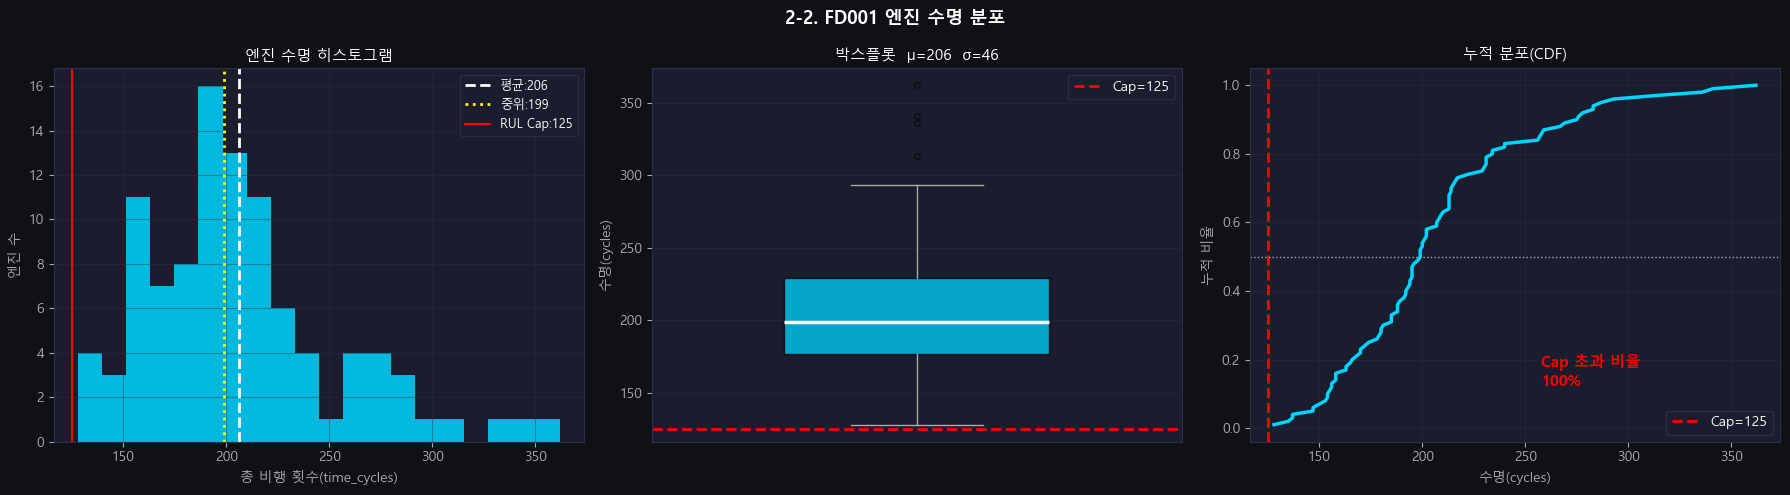


엔진 수명 통계:
  평균=206.3  중위=199.0  min=128  max=362
  Cap=125 초과 엔진: 100대 (100%)

📌 100% 엔진이 수명 125 사이클 초과 → Cap=125 설정 근거


In [5]:
lifecycles = train_raw.groupby('unit_nr')['time_cycles'].max()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('2-2. FD001 엔진 수명 분포', fontsize=13, fontweight='bold')

# 히스토그램
ax = axes[0]
ax.hist(lifecycles, bins=20, color=C[0], alpha=0.85, edgecolor='none')
ax.axvline(lifecycles.mean(),   color='white',  ls='--', lw=2, label=f'평균:{lifecycles.mean():.0f}')
ax.axvline(lifecycles.median(), color='yellow', ls=':',  lw=2, label=f'중위:{lifecycles.median():.0f}')
ax.axvline(RUL_CAP, color='red', ls='-', lw=1.5, label=f'RUL Cap:{RUL_CAP}')
ax.set_xlabel('총 비행 횟수(time_cycles)')
ax.set_ylabel('엔진 수')
ax.set_title('엔진 수명 히스토그램')
ax.legend(fontsize=9)

# 박스플롯
ax = axes[1]
bp = ax.boxplot(lifecycles, patch_artist=True, vert=True, widths=0.5,
                medianprops=dict(color='white',lw=2.5),
                whiskerprops=dict(color=GRAY), capprops=dict(color=GRAY),
                flierprops=dict(marker='o',color=GRAY,markersize=4,alpha=0.5))
bp['boxes'][0].set_facecolor(C[0]); bp['boxes'][0].set_alpha(0.75)
ax.axhline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.set_ylabel('수명(cycles)')
ax.set_title(f'박스플롯  μ={lifecycles.mean():.0f}  σ={lifecycles.std():.0f}')
ax.set_xticks([])
ax.legend()

# CDF
ax = axes[2]
lc_sorted = np.sort(lifecycles)
cdf = np.arange(1, len(lc_sorted)+1)/len(lc_sorted)
ax.plot(lc_sorted, cdf, color=C[0], lw=2.5)
ax.axvline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.axhline(0.5, color=GRAY, ls=':', lw=1)
pct_above = (lifecycles > RUL_CAP).mean()*100
ax.text(0.55, 0.15, f'Cap 초과 비율\n{pct_above:.0f}%', transform=ax.transAxes,
        fontsize=11, color='red', fontweight='bold')
ax.set_xlabel('수명(cycles)')
ax.set_ylabel('누적 비율')
ax.set_title('누적 분포(CDF)')
ax.legend()

plt.tight_layout(); plt.show()

print(f'\n엔진 수명 통계:')
print(f'  평균={lifecycles.mean():.1f}  중위={lifecycles.median():.1f}  min={lifecycles.min()}  max={lifecycles.max()}')
print(f'  Cap={RUL_CAP} 초과 엔진: {(lifecycles>RUL_CAP).sum()}대 ({pct_above:.0f}%)')
print(f'\n📌 100% 엔진이 수명 {RUL_CAP} 사이클 초과 → Cap={RUL_CAP} 설정 근거')

### 2-3. 센서 분포 & 이상치 (전처리 전)

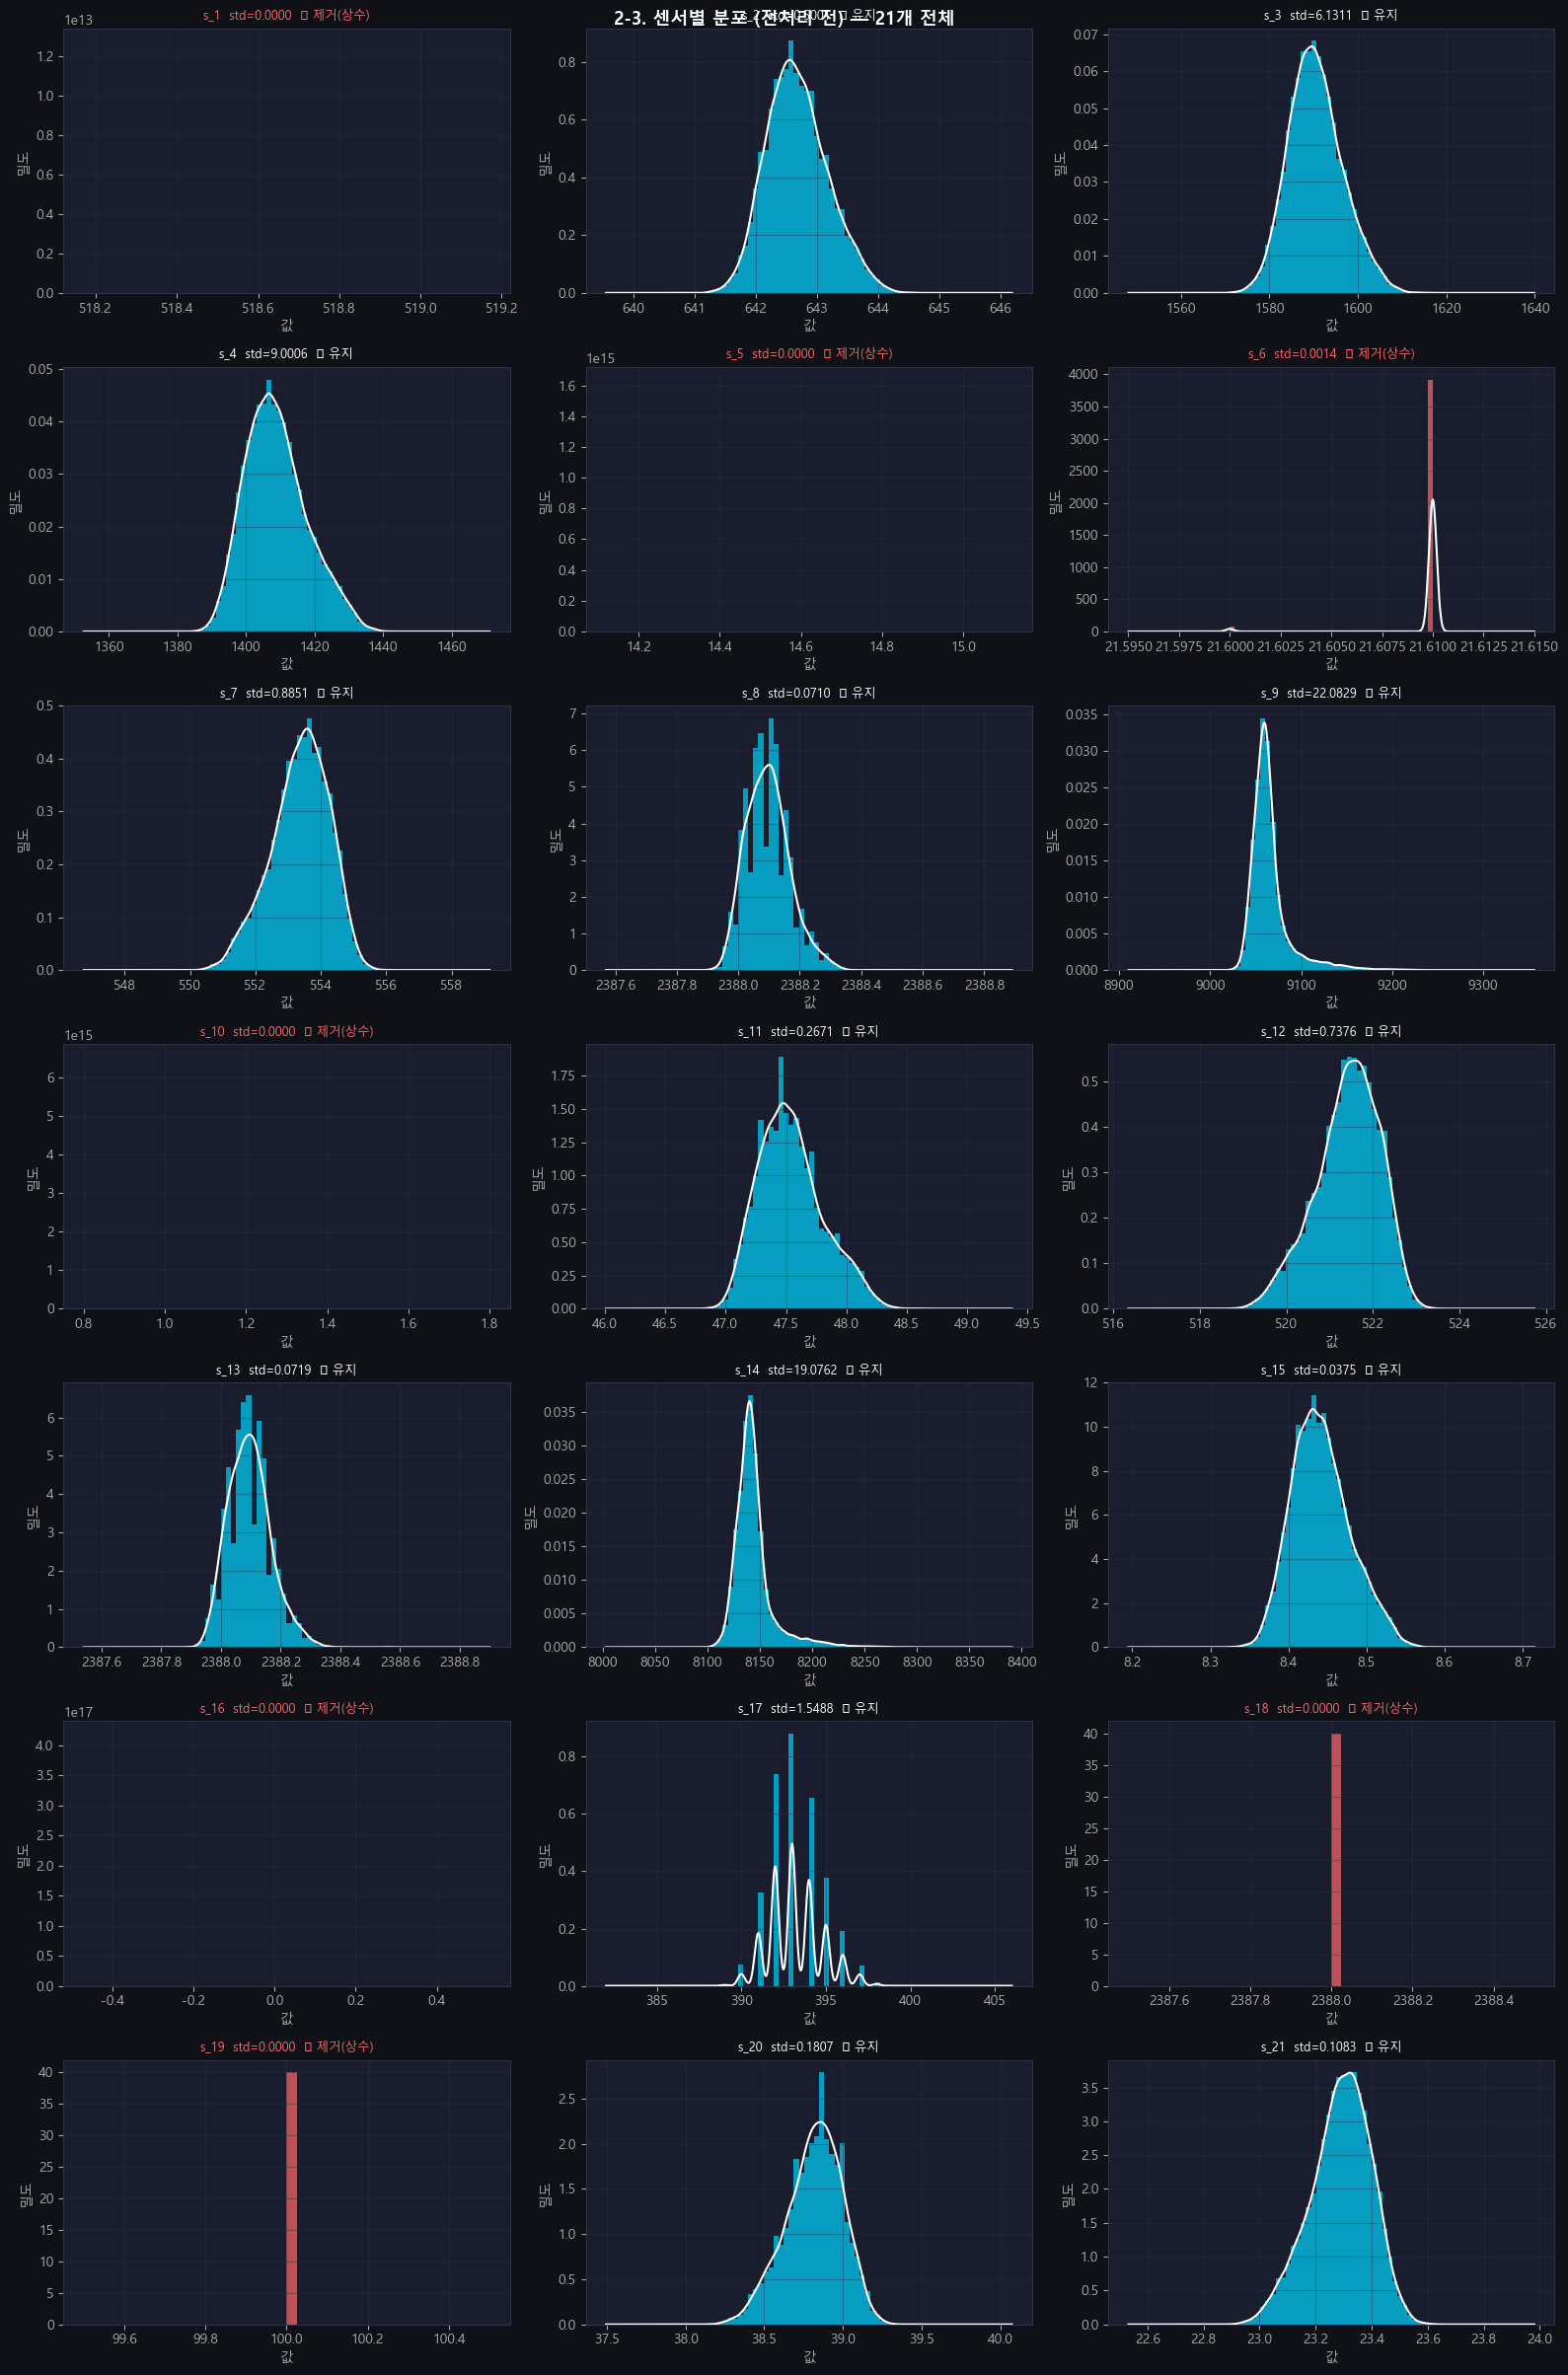

--- IQR 기준 이상치 탐지 ---


,센서,이상치 수,비율(%)
1,s_2,128,0.620
2,s_3,165,0.800
3,s_4,120,0.582
5,s_6,406,1.968
6,s_7,110,0.533
7,s_8,320,1.551
8,s_9,1686,8.172
10,s_11,167,0.809
11,s_12,146,0.708
12,s_13,161,0.780


In [6]:
# 21개 센서 분포 (히스토그램 + KDE)
n_cols, n_rows = 3, 7
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3.5))
fig.suptitle('2-3. 센서별 분포 (전처리 전) — 21개 전체', fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, SENSOR_COLS):
    data = train_raw[s].dropna()
    std_val = data.std()
    is_const = std_val < CONST_THR
    color = C[1] if is_const else C[0]
    ax.hist(data, bins=40, color=color, alpha=0.7, density=True, edgecolor='none')
    try:
        data.plot.kde(ax=ax, color='white', lw=1.5)
    except: pass
    label = '❌ 제거(상수)' if is_const else '✅ 유지'
    ax.set_title(f'{s}  std={std_val:.4f}  {label}', fontsize=9,
                 color=C[1] if is_const else WHITE)
    ax.set_xlabel('값'); ax.set_ylabel('밀도')

for ax in axes.flat[len(SENSOR_COLS):]:
    ax.set_visible(False)

plt.tight_layout(); plt.show()

# IQR 이상치 탐지
print('--- IQR 기준 이상치 탐지 ---')
outlier_rows = []
for s in SENSOR_COLS:
    Q1, Q3 = train_raw[s].quantile(0.25), train_raw[s].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((train_raw[s] < Q1-1.5*IQR)|(train_raw[s] > Q3+1.5*IQR)).sum()
    outlier_rows.append({'센서':s,'이상치 수':n_out,'비율(%)':round(n_out/len(train_raw)*100,3)})
out_df = pd.DataFrame(outlier_rows)
nonzero = out_df[out_df['이상치 수']>0]
if len(nonzero):
    display(nonzero)
else:
    print('✅ IQR 기준 이상치 없음 (시뮬레이션 데이터 특성)')

### 2-4. 센서 간 상관관계 히트맵 (전처리 전)

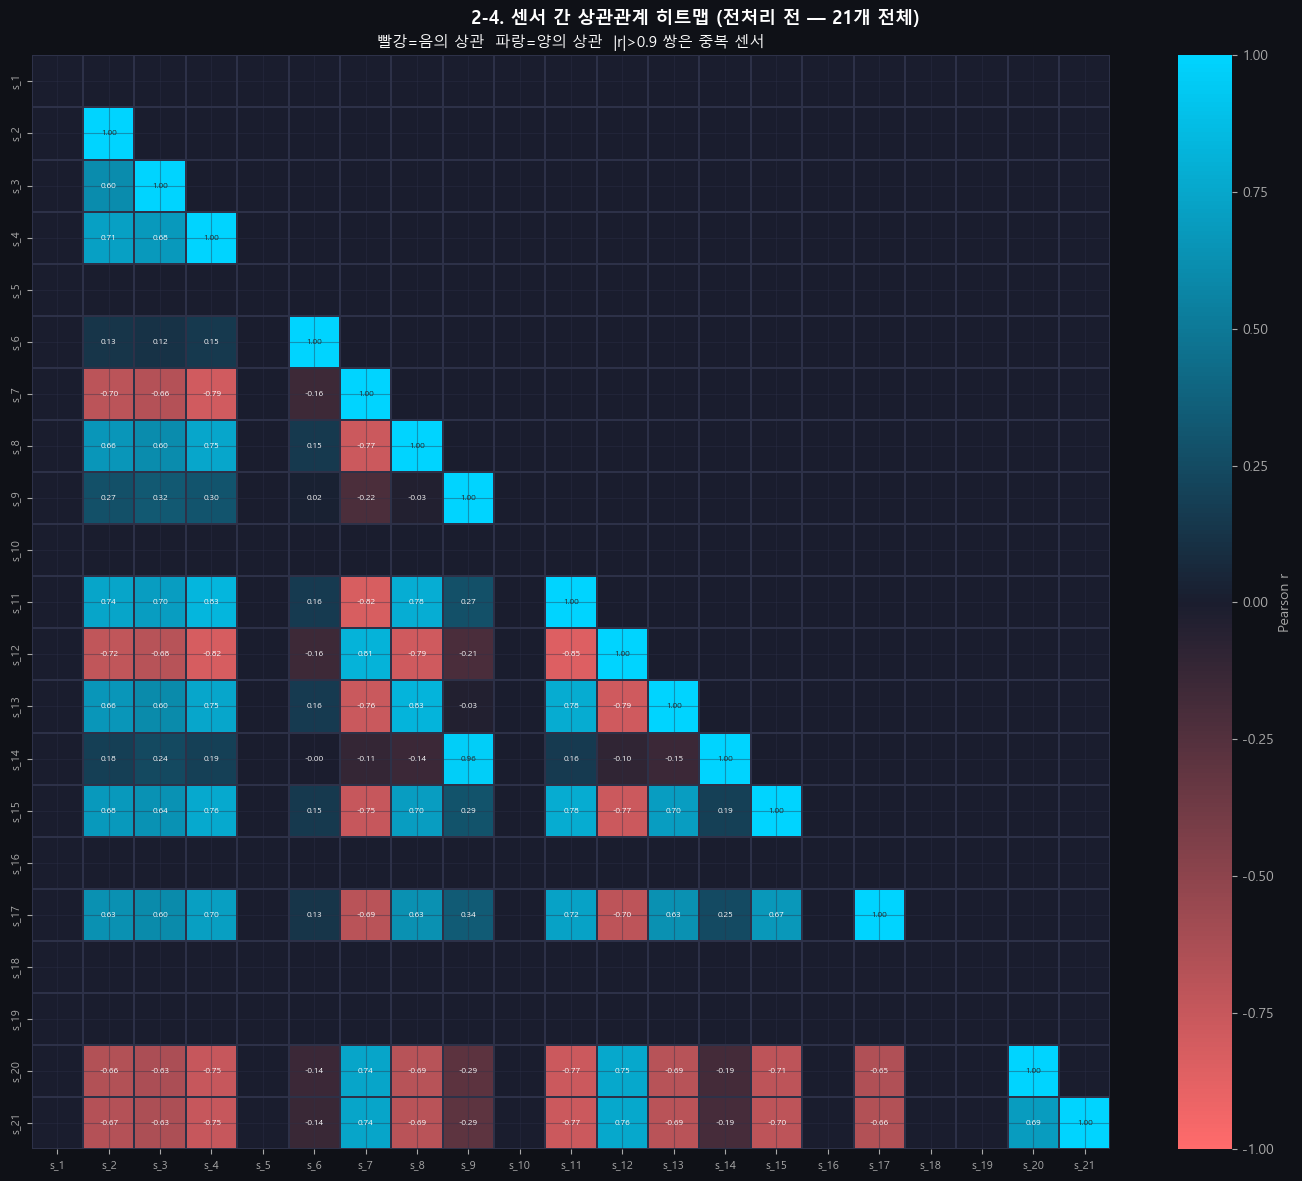

--- 고상관 센서 쌍 (|r| > 0.9) ---


,센서A,센서B,r
0,s_9,s_14,0.963


In [7]:
from matplotlib.colors import LinearSegmentedColormap

cmap_rg = LinearSegmentedColormap.from_list('rg',['#ff6b6b','#1a1d2e','#00d4ff'],N=256)

corr_before = train_raw[SENSOR_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 12))
fig.suptitle('2-4. 센서 간 상관관계 히트맵 (전처리 전 — 21개 전체)', fontsize=13, fontweight='bold')

mask = np.triu(np.ones_like(corr_before, dtype=bool), k=1)
sns.heatmap(corr_before, ax=ax, mask=mask, cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size':6}, linewidths=0.3, linecolor=GRID,
            cbar_kws={'label':'Pearson r'})
ax.set_title('빨강=음의 상관  파랑=양의 상관  |r|>0.9 쌍은 중복 센서')
ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

# 고상관 쌍
print('--- 고상관 센서 쌍 (|r| > 0.9) ---')
pairs = []
for i in range(len(SENSOR_COLS)):
    for j in range(i+1, len(SENSOR_COLS)):
        r = corr_before.iloc[i,j]
        if abs(r) > 0.9:
            pairs.append({'센서A':SENSOR_COLS[i],'센서B':SENSOR_COLS[j],'r':round(r,3)})
if pairs:
    display(pd.DataFrame(pairs))
else:
    print('  해당 없음')

### 2-5. 센서별 열화 트렌드 (전처리 전)

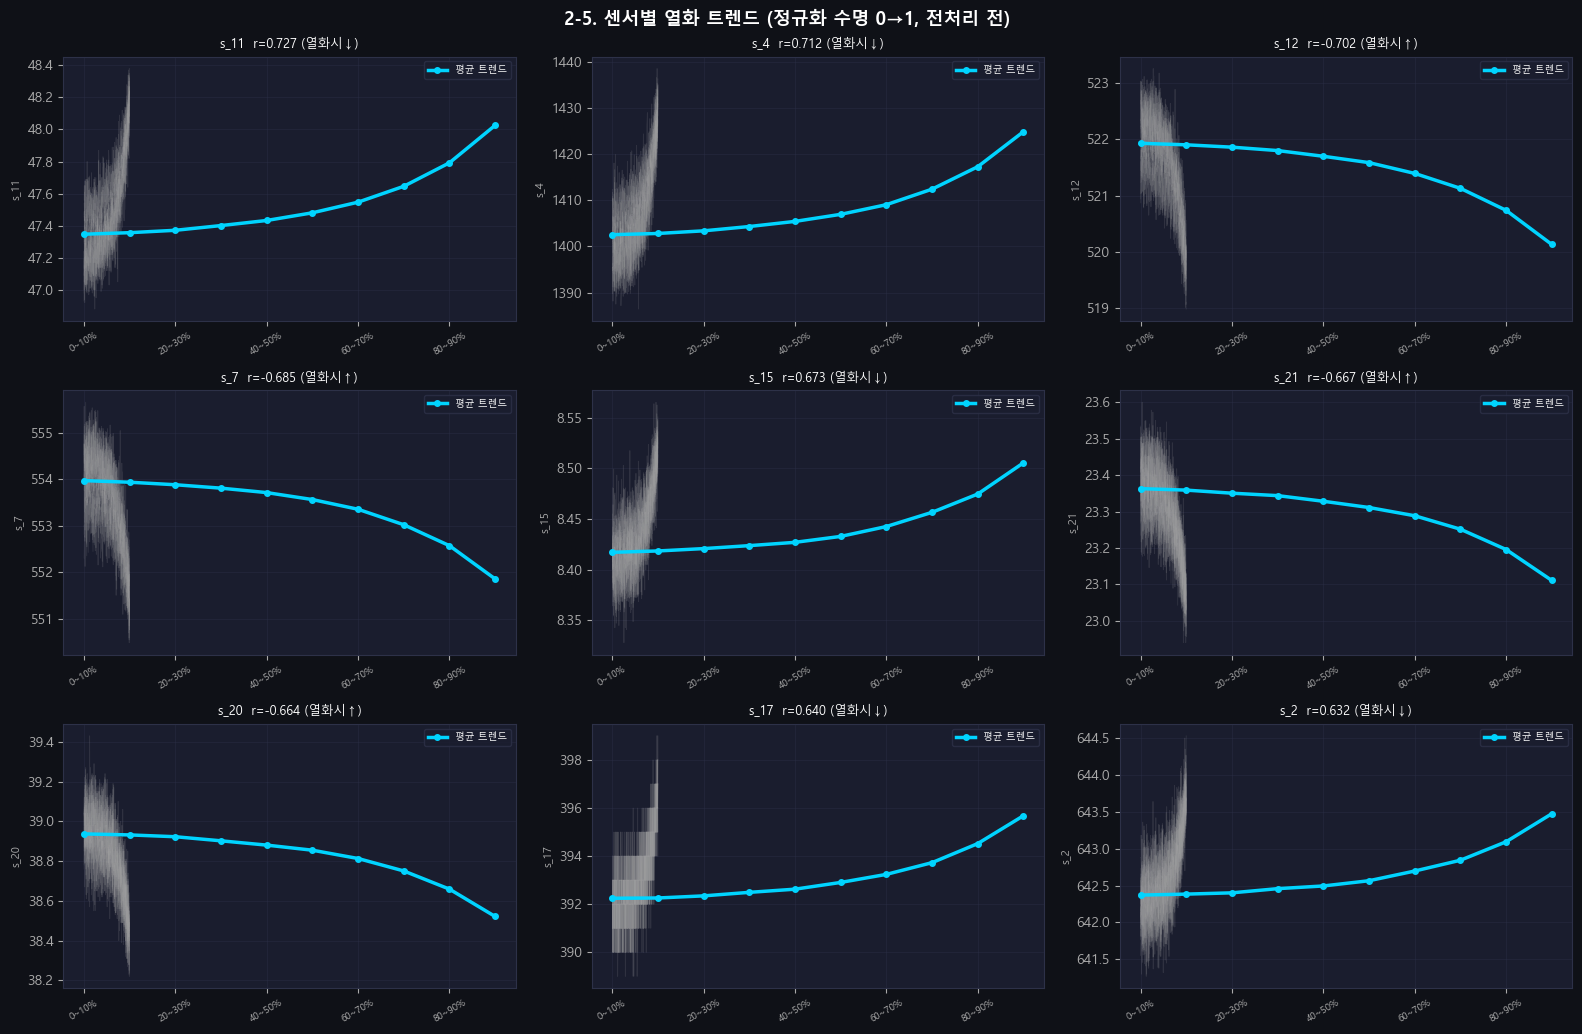

📌 r < 0: 엔진이 닳을수록 센서값 증가 (온도↑)  |  r > 0: 감소 (속도↓)


In [8]:
# 정규화 수명축(0=새것, 1=고장 직전)으로 평균 트렌드 확인
tr_trend = train_raw.copy()
mc = tr_trend.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_trend = tr_trend.join(mc, on='unit_nr')
tr_trend['norm_life'] = tr_trend['time_cycles']/tr_trend['max_c']

bins   = np.linspace(0, 1, 11)
labels = [f'{int(a*100)}~{int(b*100)}%' for a,b in zip(bins[:-1],bins[1:])]
tr_trend['life_bin'] = pd.cut(tr_trend['norm_life'], bins=bins, labels=labels)
trend_mean = tr_trend.groupby('life_bin', observed=True)[SENSOR_COLS].mean()

# 유의미한 트렌드 센서만 표시 (|corr|>0.1)
corr_with_life = tr_trend[SENSOR_COLS+['norm_life']].corr()['norm_life'][SENSOR_COLS]
trend_sensors  = corr_with_life[corr_with_life.abs()>0.1].sort_values(key=abs, ascending=False).index.tolist()
trend_sensors  = trend_sensors[:9]  # 최대 9개

n_cols = 3
n_rows = (len(trend_sensors)+n_cols-1)//n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3.5))
fig.suptitle('2-5. 센서별 열화 트렌드 (정규화 수명 0→1, 전처리 전)', fontsize=13, fontweight='bold')

x_pos = range(len(labels))
sample_units = tr_trend['unit_nr'].unique()[:15]

for ax, s in zip(axes.flat, trend_sensors):
    for u in sample_units:
        sub = tr_trend[tr_trend['unit_nr']==u].sort_values('norm_life')
        ax.plot(sub['norm_life'], sub[s], color=GRAY, alpha=0.15, lw=0.6)
    ax.plot(x_pos, trend_mean[s].values, color=C[0], lw=2.5, marker='o', markersize=4, label='평균 트렌드')
    r = corr_with_life[s]
    direction = '열화시↑' if r<0 else '열화시↓'
    ax.set_title(f'{s}  r={r:.3f} ({direction})', fontsize=9)
    ax.set_xticks(x_pos[::2])
    ax.set_xticklabels(labels[::2], rotation=30, fontsize=7)
    ax.set_ylabel(s, fontsize=8)
    ax.legend(fontsize=7)

for ax in axes.flat[len(trend_sensors):]:
    ax.set_visible(False)

plt.tight_layout(); plt.show()

print('📌 r < 0: 엔진이 닳을수록 센서값 증가 (온도↑)  |  r > 0: 감소 (속도↓)')

### 2-6. RUL 상관계수 (전처리 전)

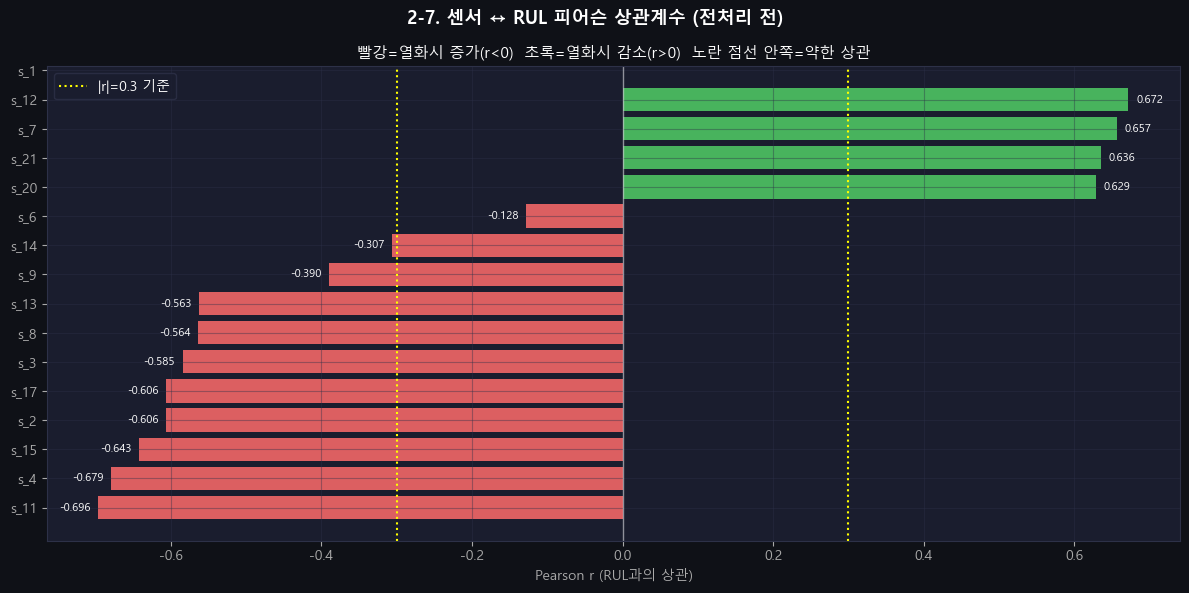

|r|>0.3 고상관 센서: 14개
  s_11: r=-0.696  Ps30 정적압력(psia)
  s_4: r=-0.679  T50 LPT 출구 온도(°R)
  s_12: r=0.672  phi 연료/Ps30 비율
  s_7: r=0.657  P30 HPC 출구 압력(psia)
  s_15: r=-0.643  BPR 바이패스 비율
  s_21: r=0.636  W32 LPT 냉각블리드
  s_20: r=0.629  W31 HPT 냉각블리드
  s_2: r=-0.606  T24 LPC 출구 온도(°R)
  s_17: r=-0.606  htBleed 블리드 엔탈피
  s_3: r=-0.585  T30 HPC 출구 온도(°R)
  s_8: r=-0.564  Nf 팬 속도(rpm)
  s_13: r=-0.563  NRf 보정 팬 속도(rpm)
  s_9: r=-0.390  Nc 코어 속도(rpm)
  s_14: r=-0.307  NRc 보정 코어속도(rpm)


In [9]:
tr_rul = train_raw.copy()
mc = tr_rul.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_rul = tr_rul.join(mc, on='unit_nr')
tr_rul['RUL'] = tr_rul['max_c'] - tr_rul['time_cycles']

rul_corr_before = tr_rul[SENSOR_COLS+['RUL']].corr()['RUL'][SENSOR_COLS].sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('2-7. 센서 ↔ RUL 피어슨 상관계수 (전처리 전)', fontsize=13, fontweight='bold')

bar_colors = [C[1] if v<0 else C[2] for v in rul_corr_before]
bars = ax.barh(rul_corr_before.index, rul_corr_before.values, color=bar_colors, alpha=0.85)
ax.axvline(0,    color='white', lw=1, alpha=0.5)
ax.axvline( 0.3, color='yellow', lw=1.5, ls=':', label='|r|=0.3 기준')
ax.axvline(-0.3, color='yellow', lw=1.5, ls=':')
ax.set_xlabel('Pearson r (RUL과의 상관)')
ax.set_title('빨강=열화시 증가(r<0)  초록=열화시 감소(r>0)  노란 점선 안쪽=약한 상관')
ax.legend()
for bar, val in zip(bars, rul_corr_before.values):
    ax.text(val+(0.01 if val>=0 else -0.01), bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)
plt.tight_layout(); plt.show()

high_corr = rul_corr_before[rul_corr_before.abs()>0.3]
print(f'|r|>0.3 고상관 센서: {len(high_corr)}개')
for s,r in high_corr.sort_values(key=abs,ascending=False).items():
    print(f'  {s}: r={r:.3f}  {SENSOR_DESC.get(s,"")[:30]}')

### 2-7. 시차상관관계 (Sensor → RUL, lag 0 ~ 15)

> **해석:** lag=k에서의 상관계수는 '현재 센서값이 k사이클 뒤의 RUL과 얼마나 관련되는가'를 의미.  
> 절댓값이 클수록, 그리고 최적 lag가 클수록 해당 센서가 **조기 경보(early warning) 능력**이 높음.


=== 2-7. 시차상관관계 — Sensor vs RUL (전처리 전, lag 0~15) ===


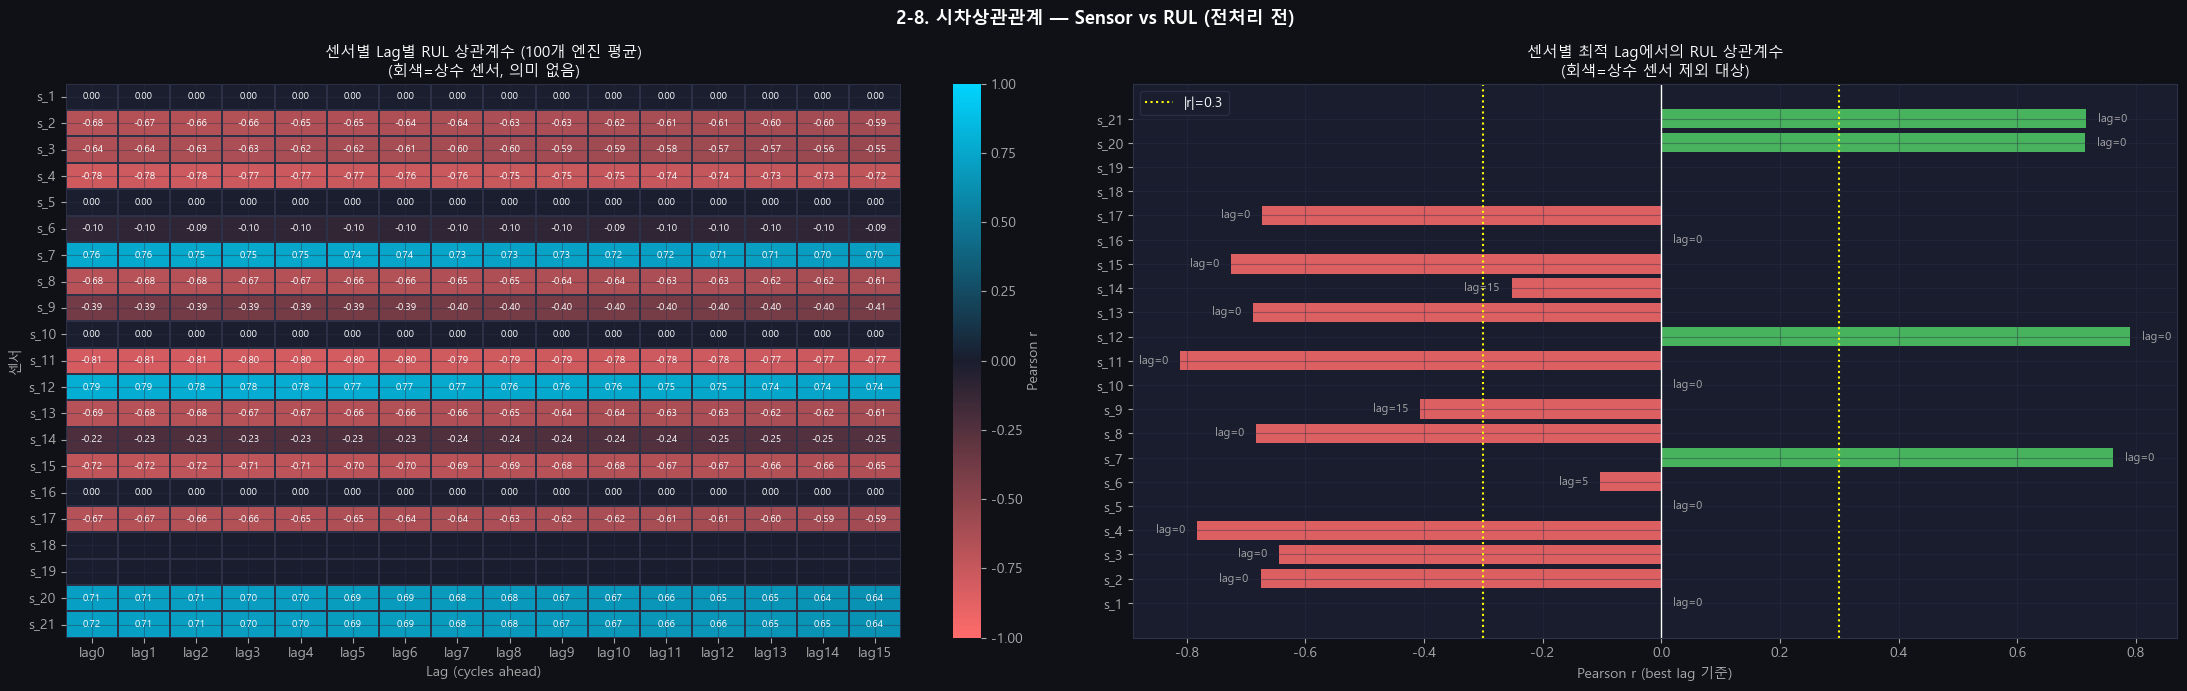


--- 시차상관관계 요약 ---


,최적 lag (cycles),상관계수 (r),조기경보 능력,센서 설명
센서,,,,
s_1,0,0.0000,❌ 약함,T2 팬 입구 온도(°R)
s_2,0,-0.6753,✅ 강함,T24 LPC 출구 온도(°R)
s_3,0,-0.6440,✅ 강함,T30 HPC 출구 온도(°R)
s_4,0,-0.7816,✅ 강함,T50 LPT 출구 온도(°R)
s_5,0,0.0000,❌ 약함,P2 팬 입구 압력(psia)
s_6,5,-0.1034,❌ 약함,P15 바이패스 압력(psia)
s_7,0,0.7615,✅ 강함,P30 HPC 출구 압력(psia)
s_8,0,-0.6835,✅ 강함,Nf 팬 속도(rpm)
s_9,15,-0.4060,🔶 보통,Nc 코어 속도(rpm)


In [10]:
print('=== 2-7. 시차상관관계 — Sensor vs RUL (전처리 전, lag 0~15) ===')

MAX_LAG = 15
LAGS    = list(range(0, MAX_LAG + 1))

lag_matrix = np.full((len(SENSOR_COLS), len(LAGS)), np.nan)

for si, s in enumerate(SENSOR_COLS):
    unit_lag_corrs = {lag: [] for lag in LAGS}
    for uid in tr_rul['unit_nr'].unique():
        udf    = tr_rul[tr_rul['unit_nr'] == uid].sort_values('time_cycles')
        sensor = udf[s].values
        rul    = udf['RUL'].values
        for lag in LAGS:
            if len(sensor) > lag + 5:
                c = np.corrcoef(sensor[:len(sensor) - lag], rul[lag:])[0, 1]
                if np.isfinite(c):
                    unit_lag_corrs[lag].append(c)
    lag_matrix[si] = [
        np.mean(unit_lag_corrs[l]) if unit_lag_corrs[l] else np.nan
        for l in LAGS
    ]

lag_df = pd.DataFrame(lag_matrix, index=SENSOR_COLS,
                       columns=[f'lag{l}' for l in LAGS])

# ── 안전한 best_lag 계산 (상수 센서 = all-NaN 행 처리) ────────────
best_lag_idx, best_lag_corr = [], []
for i in range(len(SENSOR_COLS)):
    row = lag_matrix[i]
    if np.all(np.isnan(row)):           # 상수 센서 → 의미 없는 행
        best_lag_idx.append(0)
        best_lag_corr.append(np.nan)
    else:
        idx = int(np.nanargmax(np.abs(row)))
        best_lag_idx.append(idx)
        best_lag_corr.append(float(row[idx]))

# 시각화용: NaN 센서는 0으로 대체 (막대 미표시 처리)
best_lag_corr_plot = [v if np.isfinite(v) else 0.0 for v in best_lag_corr]

# ── 시각화 ──────────────────────────────────────────────────────
from matplotlib.colors import LinearSegmentedColormap
cmap_lag = LinearSegmentedColormap.from_list('lag', ['#ff6b6b', '#1a1d2e', '#00d4ff'], N=256)

fig, axes = plt.subplots(1, 2, figsize=(22, 7))
fig.suptitle('2-8. 시차상관관계 — Sensor vs RUL (전처리 전)', fontsize=13, fontweight='bold')

sns.heatmap(lag_df, ax=axes[0], cmap=cmap_lag, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.3, linecolor=GRID, cbar_kws={'label': 'Pearson r'})
axes[0].set_title('센서별 Lag별 RUL 상관계수 (100개 엔진 평균)\n(회색=상수 센서, 의미 없음)')
axes[0].set_xlabel('Lag (cycles ahead)')
axes[0].set_ylabel('센서')

bar_colors = [GRAY if not np.isfinite(v)
              else (C[1] if v < 0 else C[2])
              for v in best_lag_corr]
bars = axes[1].barh(SENSOR_COLS, best_lag_corr_plot, color=bar_colors, alpha=0.85)
axes[1].axvline(0,    color='white',  lw=1)
axes[1].axvline( 0.3, color='yellow', lw=1.5, ls=':', label='|r|=0.3')
axes[1].axvline(-0.3, color='yellow', lw=1.5, ls=':')
for bar, li, v in zip(bars, best_lag_idx, best_lag_corr):
    if not np.isfinite(v):
        continue
    x = bar.get_width()
    axes[1].text(x + (0.02 if x >= 0 else -0.02),
                 bar.get_y() + bar.get_height() / 2,
                 f'lag={LAGS[li]}', va='center',
                 ha='left' if x >= 0 else 'right',
                 fontsize=8, color=GRAY)
axes[1].set_title('센서별 최적 Lag에서의 RUL 상관계수\n(회색=상수 센서 제외 대상)')
axes[1].set_xlabel('Pearson r (best lag 기준)')
axes[1].legend()
plt.tight_layout(); plt.show()

lag_summary = pd.DataFrame({
    '최적 lag (cycles)': [LAGS[i] for i in best_lag_idx],
    '상관계수 (r)'     : [round(v, 4) if np.isfinite(v) else np.nan for v in best_lag_corr],
    '조기경보 능력'    : ['⬜ 상수 센서' if not np.isfinite(v)
                         else ('✅ 강함' if abs(v) >= 0.5
                         else ('🔶 보통' if abs(v) >= 0.3
                         else '❌ 약함')) for v in best_lag_corr],
    '센서 설명'        : [SENSOR_DESC.get(s, s) for s in SENSOR_COLS],
}, index=SENSOR_COLS)
lag_summary.index.name = '센서'
print('\n--- 시차상관관계 요약 ---')
display(lag_summary)


### 2-8. Mann-Kendall 트렌드 검정 (전처리 전)

> **원리:** Kendall τ 기반 비모수 단조 트렌드 검정 — 정규성 가정 불필요.  
> τ > 0 → 상승 / τ < 0 → 하강 / **p < 0.05 → 유의한 트렌드 존재**  
> **유의 엔진 비율 ≥ 70%** → 해당 센서가 열화 신호를 안정적으로 보유함


=== 2-8. Mann-Kendall 트렌드 검정 (전처리 전, 100개 엔진) ===
τ > 0 → 상승 트렌드  |  τ < 0 → 하강 트렌드  |  p < 0.05 → 유의



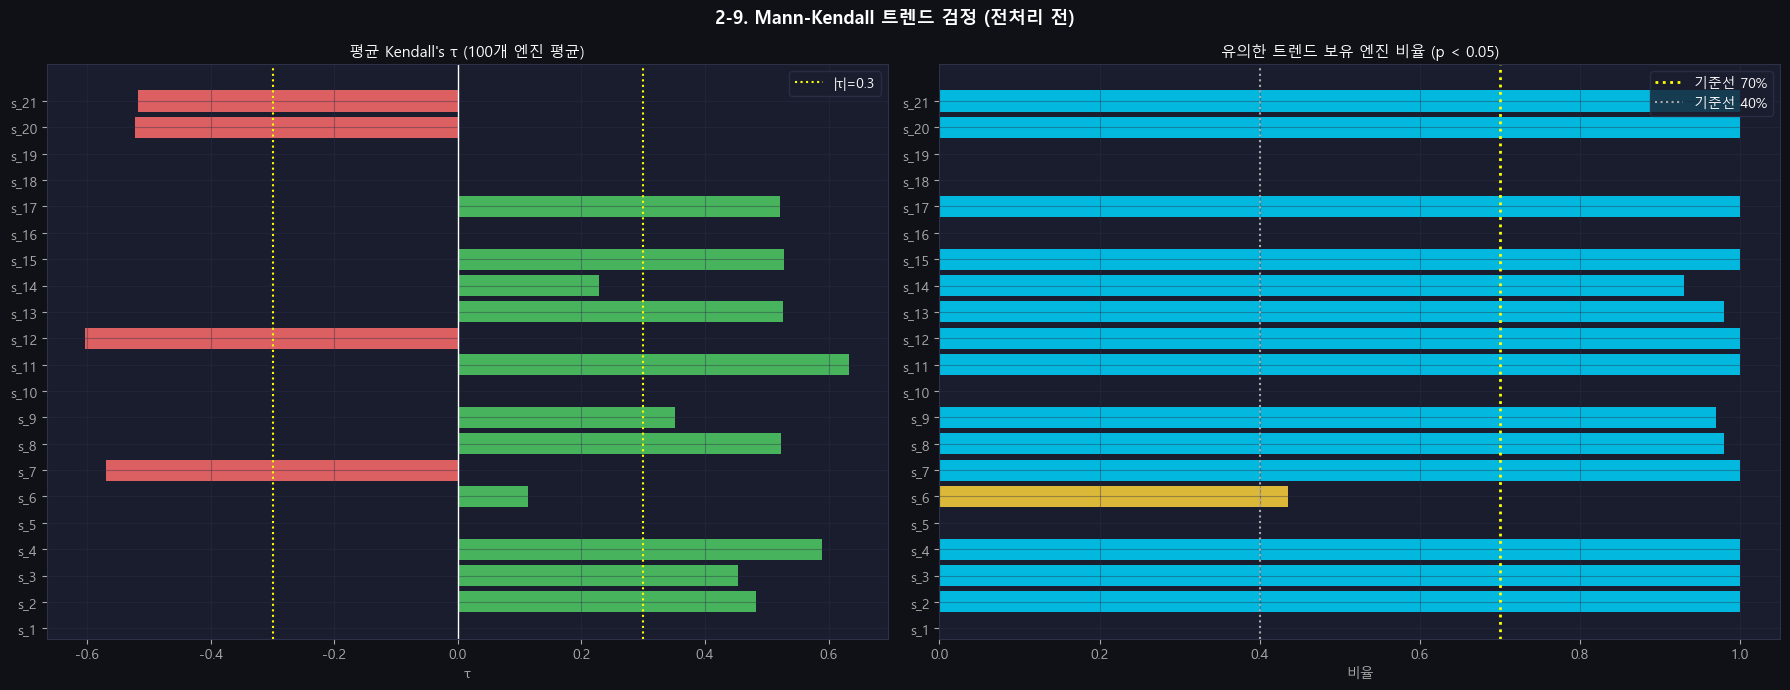


--- Mann-Kendall 검정 결과 요약 ---


,평균 τ,트렌드 방향,유의 엔진 비율,열화 신호 판정,센서 설명
센서,,,,,
s_1,NaN,하강 ↓,nan%,❌ 약함,T2 팬 입구 온도(°R)
s_2,0.4826,상승 ↑,100.0%,✅ 강함,T24 LPC 출구 온도(°R)
s_3,0.4527,상승 ↑,100.0%,✅ 강함,T30 HPC 출구 온도(°R)
s_4,0.5889,상승 ↑,100.0%,✅ 강함,T50 LPT 출구 온도(°R)
s_5,NaN,하강 ↓,nan%,❌ 약함,P2 팬 입구 압력(psia)
s_6,0.1134,상승 ↑,43.5%,🔶 보통,P15 바이패스 압력(psia)
s_7,-0.5695,하강 ↓,100.0%,✅ 강함,P30 HPC 출구 압력(psia)
s_8,0.5229,상승 ↑,98.0%,✅ 강함,Nf 팬 속도(rpm)
s_9,0.3516,상승 ↑,97.0%,✅ 강함,Nc 코어 속도(rpm)


In [11]:
from scipy.stats import kendalltau

print('=== 2-8. Mann-Kendall 트렌드 검정 (전처리 전, 100개 엔진) ===')
print('τ > 0 → 상승 트렌드  |  τ < 0 → 하강 트렌드  |  p < 0.05 → 유의')
print()

def mann_kendall(series):
    """Kendall τ 기반 Mann-Kendall 트렌드 검정 (scipy 활용)"""
    t = np.arange(len(series))
    tau, p = kendalltau(t, series)
    return tau, p

mk_rows = []
for s in SENSOR_COLS:
    taus, ps = [], []
    for uid in tr_rul['unit_nr'].unique():
        arr = (tr_rul[tr_rul['unit_nr'] == uid]
               .sort_values('time_cycles')[s].values)
        if len(arr) >= 8:
            tau, p = mann_kendall(arr)
            if np.isfinite(tau):
                taus.append(tau)
                ps.append(p)

    mean_tau  = np.mean(taus)  if taus else np.nan
    sig_ratio = np.mean([p < 0.05 for p in ps]) if ps else np.nan

    mk_rows.append({
        '센서'           : s,
        '평균 τ'         : round(mean_tau, 4),
        '트렌드 방향'    : '상승 ↑' if mean_tau > 0 else '하강 ↓',
        '유의 엔진 비율' : f'{sig_ratio*100:.1f}%',
        '열화 신호 판정' : ('✅ 강함' if sig_ratio >= 0.7
                            else '🔶 보통' if sig_ratio >= 0.4
                            else '❌ 약함'),
        '센서 설명'      : SENSOR_DESC.get(s, s),
    })

mk_df = pd.DataFrame(mk_rows).set_index('센서')

# ── 시각화 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('2-9. Mann-Kendall 트렌드 검정 (전처리 전)', fontsize=13, fontweight='bold')

tau_vals = mk_df['평균 τ'].values
bc_tau   = [C[2] if v > 0 else C[1] for v in tau_vals]
axes[0].barh(mk_df.index, tau_vals, color=bc_tau, alpha=0.85)
axes[0].axvline(0,    color='white',  lw=1)
axes[0].axvline( 0.3, color='yellow', lw=1.5, ls=':', label='|τ|=0.3')
axes[0].axvline(-0.3, color='yellow', lw=1.5, ls=':')
axes[0].set_title("평균 Kendall's τ (100개 엔진 평균)")
axes[0].set_xlabel('τ')
axes[0].legend()

sig_vals = [float(v.replace('%', '')) / 100 for v in mk_df['유의 엔진 비율'].values]
bc_sig   = [C[0] if v >= 0.7 else C[3] if v >= 0.4 else C[1] for v in sig_vals]
axes[1].barh(mk_df.index, sig_vals, color=bc_sig, alpha=0.85)
axes[1].axvline(0.7, color='yellow', lw=2,   ls=':', label='기준선 70%')
axes[1].axvline(0.4, color=GRAY,     lw=1.5, ls=':', label='기준선 40%')
axes[1].set_title('유의한 트렌드 보유 엔진 비율 (p < 0.05)')
axes[1].set_xlabel('비율')
axes[1].legend()
plt.tight_layout(); plt.show()

print('\n--- Mann-Kendall 검정 결과 요약 ---')
display(mk_df)


### 2-9. 대응 표본 검정 — 초기(RUL 상위 20%) vs 말기(RUL 하위 80%)

> **설계:** 같은 엔진 내에서 수명 초반 20%(RUL 상위 20%)와 나머지 80%(하위 80%)의 센서 평균을 1쌍으로 구성,  
> 100개 엔진 쌍에 대해 대응 검정 수행.  
> 차이값의 **Shapiro-Wilk 정규성 검정** 결과에 따라 자동 선택:  
> - 정규 → **Paired t-test**  
> - 비정규 → **Wilcoxon 부호순위 검정**  
> p < 0.05 → 초기와 말기 사이 센서 평균이 유의하게 다름 → **열화 탐지 가능**


=== 2-9. 대응 표본 검정 — 초기 vs 말기 센서 평균 (전처리 전) ===
분리 기준: 엔진별 RUL 80th 퍼센타일 기준 — 상위 20%(초기 구간) vs 하위 80%(말기 구간)



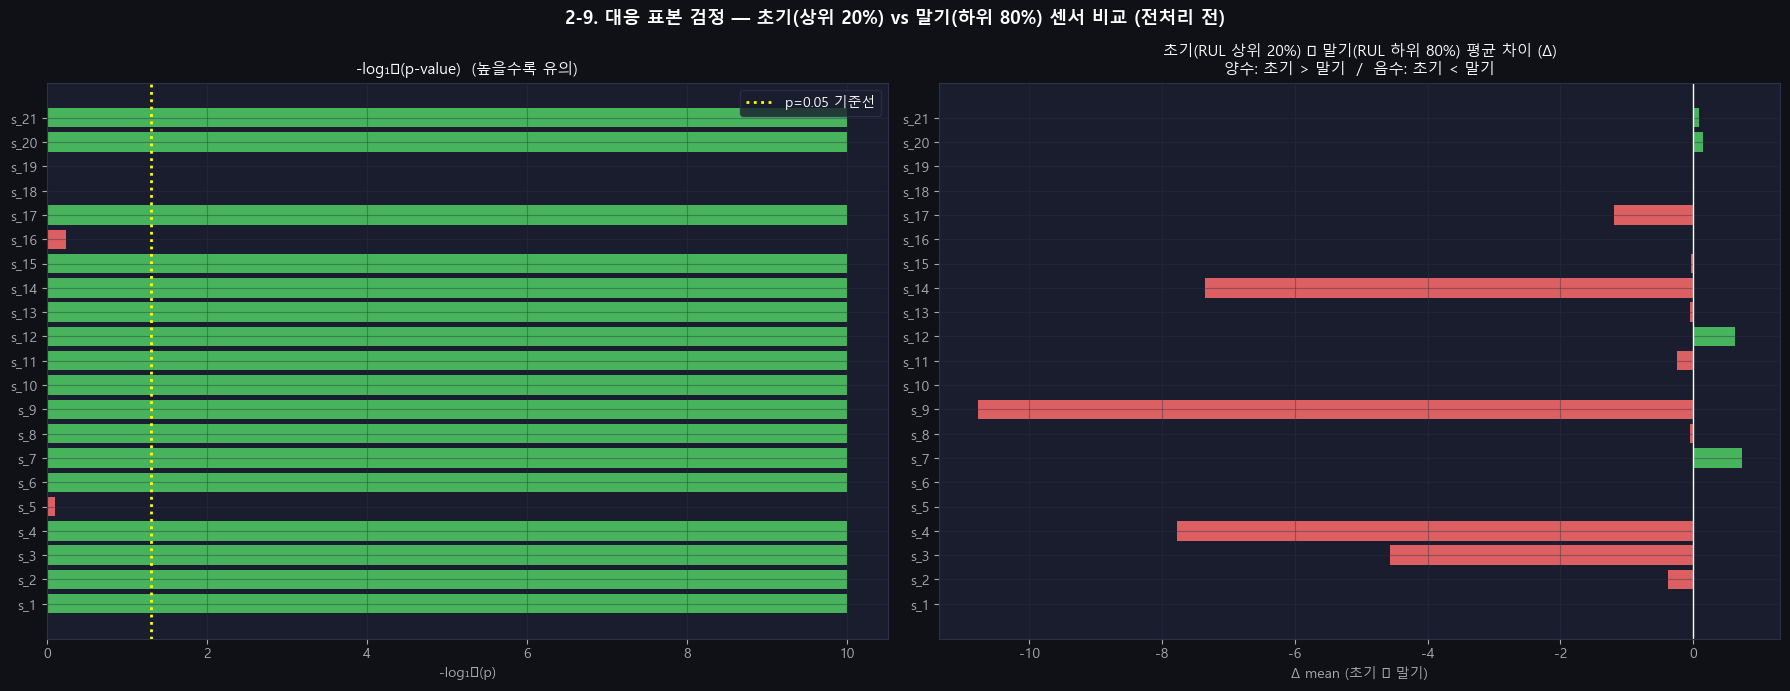


--- 대응 표본 검정 결과 요약 ---


,초기 평균,말기 평균,평균 차이(Δ),검정 방법,p-value,판정
센서,,,,,,
s_1,518.6700,518.6700,-0.0000,Wilcoxon,0.0000,유의 ✅
s_2,642.3904,642.7660,-0.3756,Paired t-test,0.0000,유의 ✅
s_3,1586.9632,1591.5232,-4.5600,Paired t-test,0.0000,유의 ✅
s_4,1402.8838,1410.6641,-7.7804,Paired t-test,0.0000,유의 ✅
s_5,14.6200,14.6200,0.0000,Wilcoxon,0.8036,비유의 ⚠️
s_6,21.6096,21.6099,-0.0003,Wilcoxon,0.0000,유의 ✅
s_7,553.9350,553.2016,0.7334,Paired t-test,0.0000,유의 ✅
s_8,2388.0597,2388.1087,-0.0489,Wilcoxon,0.0000,유의 ✅
s_9,9056.1332,9066.9104,-10.7772,Wilcoxon,0.0000,유의 ✅



유의한 센서 수: 17 / 21개
사용된 검정: {'Paired t-test': 11, 'Wilcoxon': 10}


In [12]:
from scipy.stats import ttest_rel, shapiro, wilcoxon

print('=== 2-9. 대응 표본 검정 — 초기 vs 말기 센서 평균 (전처리 전) ===')
print('분리 기준: 엔진별 RUL 80th 퍼센타일 기준 — 상위 20%(초기 구간) vs 하위 80%(말기 구간)')
print()

paired_rows = []
for s in SENSOR_COLS:
    early_means, late_means = [], []
    for uid in tr_rul['unit_nr'].unique():
        udf     = tr_rul[tr_rul['unit_nr'] == uid].sort_values('time_cycles')
        thresh  = udf['RUL'].quantile(0.80)   # 상위 20% 구간 경계
        early   = udf[udf['RUL'] >  thresh][s].mean()  # 상위 20% (초기)
        late    = udf[udf['RUL'] <= thresh][s].mean()  # 하위 80% (말기)
        if np.isfinite(early) and np.isfinite(late):
            early_means.append(early)
            late_means.append(late)

    diffs = np.array(early_means) - np.array(late_means)

    # Shapiro-Wilk 정규성 검정 (차이값 기준)
    _, p_sw = shapiro(diffs) if len(diffs) >= 3 else (np.nan, 0.0)

    if p_sw > 0.05:                              # 정규 → Paired t-test
        stat, p_val = ttest_rel(early_means, late_means)
        test_name   = 'Paired t-test'
    else:                                        # 비정규 → Wilcoxon
        stat, p_val = wilcoxon(diffs)
        test_name   = 'Wilcoxon'

    paired_rows.append({
        '센서'         : s,
        '초기 평균'    : round(np.mean(early_means), 4),
        '말기 평균'    : round(np.mean(late_means),  4),
        '평균 차이(Δ)' : round(float(np.mean(diffs)), 4),
        '검정 방법'    : test_name,
        'p-value'      : round(p_val, 4),
        '판정'         : '유의 ✅' if p_val < 0.05 else '비유의 ⚠️',
        '센서 설명'    : SENSOR_DESC.get(s, s),
    })

paired_df = pd.DataFrame(paired_rows).set_index('센서')

# ── 시각화 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('2-9. 대응 표본 검정 — 초기(상위 20%) vs 말기(하위 80%) 센서 비교 (전처리 전)',
             fontsize=13, fontweight='bold')

p_vals = paired_df['p-value'].values
log_p  = -np.log10(np.clip(p_vals, 1e-10, 1))
bc_p   = [C[2] if p < 0.05 else C[1] for p in p_vals]
axes[0].barh(paired_df.index, log_p, color=bc_p, alpha=0.85)
axes[0].axvline(-np.log10(0.05), color='yellow', lw=2, ls=':', label='p=0.05 기준선')
axes[0].set_title('-log₁₀(p-value)  (높을수록 유의)')
axes[0].set_xlabel('-log₁₀(p)')
axes[0].legend()

diff_vals = paired_df['평균 차이(Δ)'].values
bc_d      = [C[2] if v > 0 else C[1] for v in diff_vals]
axes[1].barh(paired_df.index, diff_vals, color=bc_d, alpha=0.85)
axes[1].axvline(0, color='white', lw=1)
axes[1].set_title('초기(RUL 상위 20%) − 말기(RUL 하위 80%) 평균 차이 (Δ)\n양수: 초기 > 말기  /  음수: 초기 < 말기')
axes[1].set_xlabel('Δ mean (초기 − 말기)')
plt.tight_layout(); plt.show()

print('\n--- 대응 표본 검정 결과 요약 ---')
display(paired_df.drop(columns=['센서 설명']))
print(f"\n유의한 센서 수: {(paired_df['판정'] == '유의 ✅').sum()} / {len(paired_df)}개")
print(f"사용된 검정: {paired_df['검정 방법'].value_counts().to_dict()}")


---
## 3. 결정 1 — 상수 센서 제거 (21개 → 14개)

**근거:** 비행 내내 값이 거의 변하지 않는 센서는 열화 정보를 담지 못함. 기준: `std < 0.01`  
> ⚠️ 기준은 **train**에서만 계산 → **동일 피처 목록**을 test에 적용 (누수 방지)

제거 (7개): ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
유지 (14개): ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


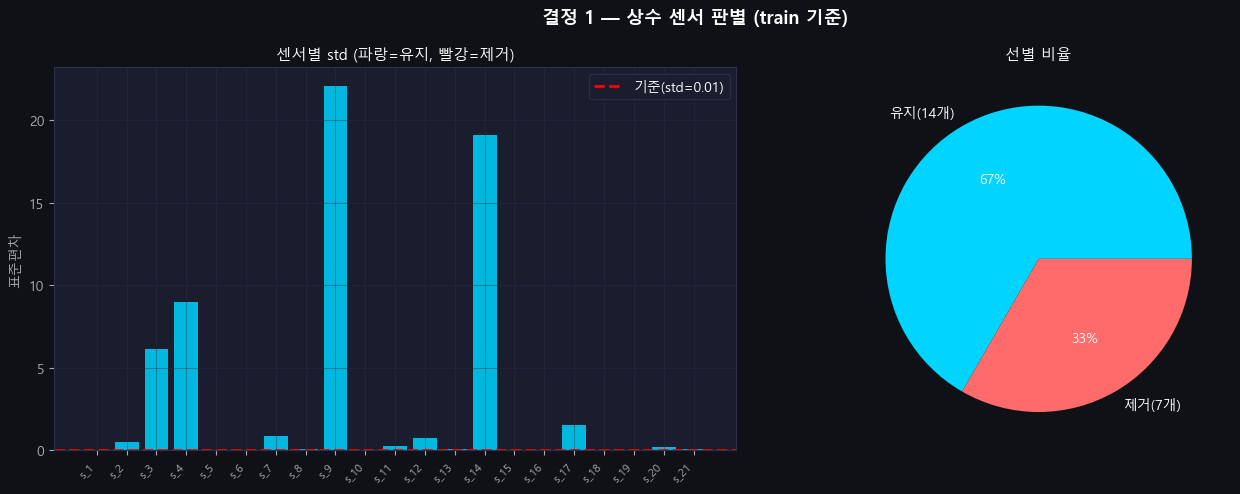


✅ 결정 1 완료: 26 → 19 컬럼


In [13]:
train_std      = train_raw[SENSOR_COLS].std()
USEFUL_SENSORS = train_std[train_std >= CONST_THR].index.tolist()
CONST_SENSORS  = train_std[train_std <  CONST_THR].index.tolist()

print(f'제거 ({len(CONST_SENSORS)}개): {CONST_SENSORS}')
print(f'유지 ({len(USEFUL_SENSORS)}개): {USEFUL_SENSORS}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('결정 1 — 상수 센서 판별 (train 기준)', fontsize=13, fontweight='bold')

ax = axes[0]
colors = [C[0] if s in USEFUL_SENSORS else C[1] for s in SENSOR_COLS]
ax.bar(range(len(SENSOR_COLS)), train_std.values, color=colors, alpha=0.85)
ax.axhline(CONST_THR, color='red', ls='--', lw=2, label=f'기준(std={CONST_THR})')
ax.set_xticks(range(len(SENSOR_COLS)))
ax.set_xticklabels(SENSOR_COLS, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('표준편차')
ax.set_title('센서별 std (파랑=유지, 빨강=제거)')
ax.legend()

ax = axes[1]
ax.pie([len(USEFUL_SENSORS), len(CONST_SENSORS)],
       labels=[f'유지({len(USEFUL_SENSORS)}개)', f'제거({len(CONST_SENSORS)}개)'],
       colors=[C[0], C[1]], autopct='%1.0f%%',
       textprops={'color':WHITE})
ax.set_title('선별 비율')
plt.tight_layout(); plt.show()

# 적용 (train 기준 피처 → test에도 동일 적용)
KEEP = ID_COLS + OP_COLS + USEFUL_SENSORS
train_s1 = train_raw[KEEP].copy()
test_s1  = test_raw[KEEP].copy()   # train 기준 피처 목록 그대로

print(f'\n✅ 결정 1 완료: {train_raw.shape[1]} → {train_s1.shape[1]} 컬럼')

## 4. 결정 2 — Piecewise RUL 생성 (Cap = 125)

**근거:** 100% 엔진이 수명 125 초과. 마지막 125 사이클(위험 구간)에만 모델이 집중하도록 함.  
> **train 전용** — test의 RUL은 `RUL_FD001.txt`에서 직접 가져옴

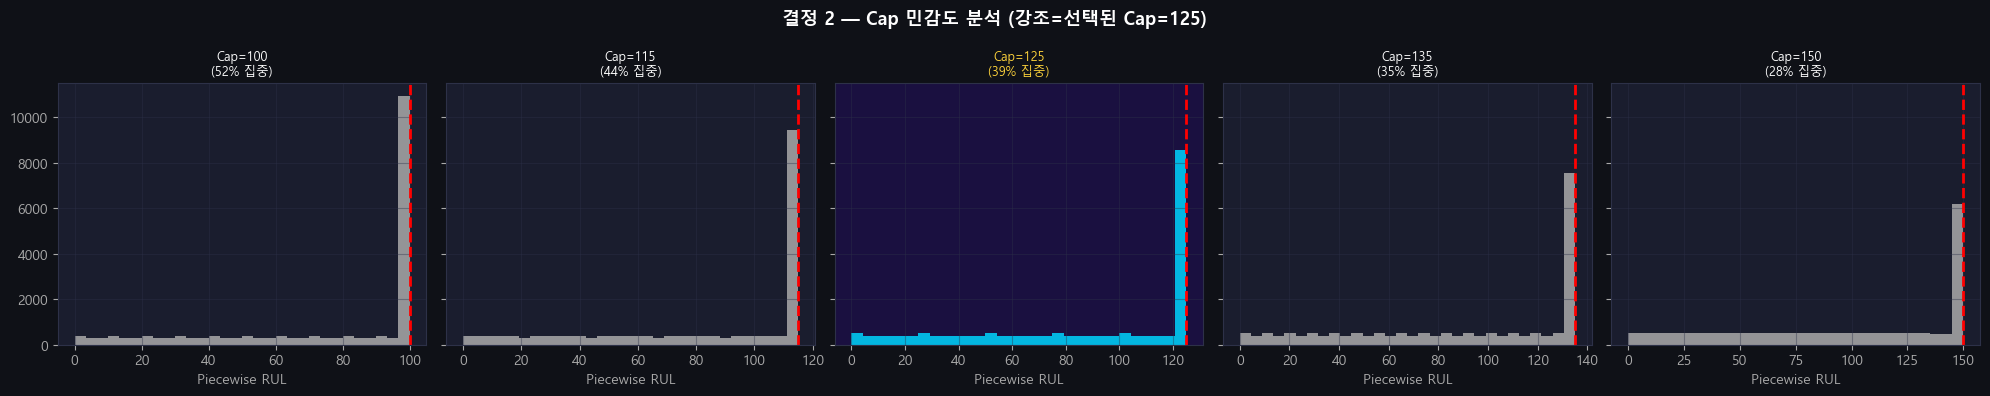

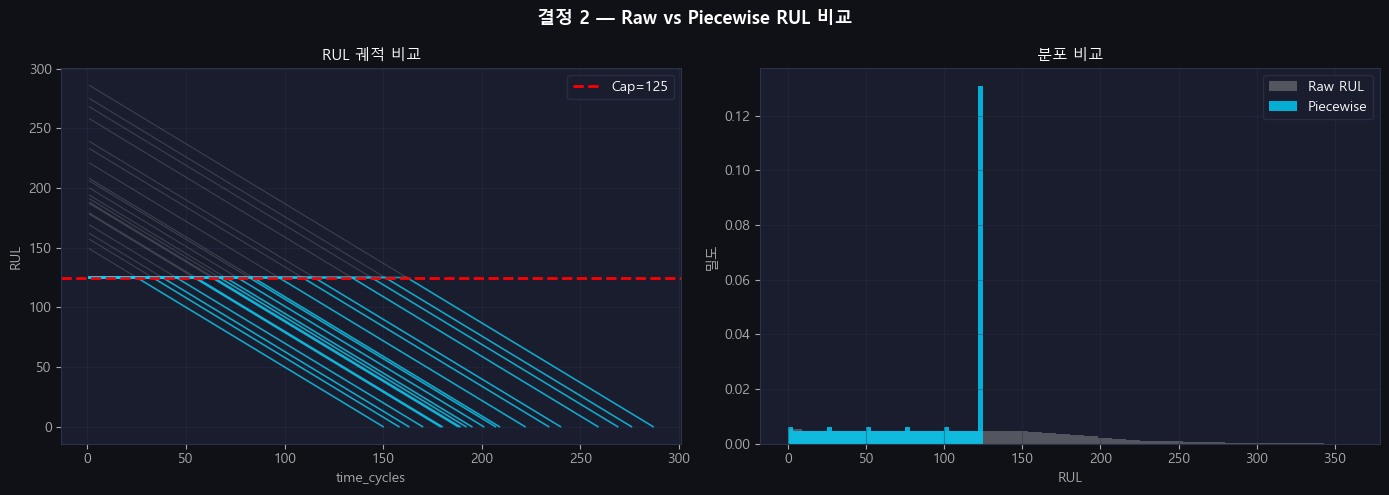

✅ 결정 2 완료  |  RUL std: 68.9 → 41.7 (39% 감소)


In [14]:
def add_piecewise_rul(df, cap=RUL_CAP):
    df = df.copy()
    mc = df.groupby('unit_nr')['time_cycles'].max().rename('max_c')
    df = df.join(mc, on='unit_nr')
    df['RUL_raw'] = df['max_c'] - df['time_cycles']
    df['RUL']     = df['RUL_raw'].clip(upper=cap)
    return df.drop('max_c', axis=1)

train_s2 = add_piecewise_rul(train_s1)
test_s2  = test_s1.copy()

# Cap 민감도 분석
caps = [100, 115, 125, 135, 150]
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle('결정 2 — Cap 민감도 분석 (강조=선택된 Cap=125)', fontsize=13, fontweight='bold')

for ax, cap in zip(axes, caps):
    tmp = train_s2['RUL_raw'].clip(upper=cap)
    pct = (train_s2['RUL_raw']>=cap).mean()*100
    ax.hist(tmp, bins=30, color=C[0] if cap==125 else GRAY, alpha=0.85, edgecolor='none')
    ax.axvline(cap, color='red', ls='--', lw=2)
    ax.set_title(f'Cap={cap}\n({pct:.0f}% 집중)',
                 color='#ffd43b' if cap==125 else WHITE, fontsize=9)
    ax.set_xlabel('Piecewise RUL')
    if cap==125: ax.patch.set_facecolor('#1a1040')
plt.tight_layout(); plt.show()

# 전후 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('결정 2 — Raw vs Piecewise RUL 비교', fontsize=13, fontweight='bold')

ax = axes[0]
for u in train_s2['unit_nr'].unique()[:20]:
    sub = train_s2[train_s2['unit_nr']==u].sort_values('time_cycles')
    ax.plot(sub['time_cycles'], sub['RUL_raw'], color=GRAY,  alpha=0.25, lw=0.8)
    ax.plot(sub['time_cycles'], sub['RUL'],     color=C[0], alpha=0.7,  lw=1.2)
ax.axhline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.set_xlabel('time_cycles'); ax.set_ylabel('RUL'); ax.set_title('RUL 궤적 비교'); ax.legend()

ax = axes[1]
ax.hist(train_s2['RUL_raw'], bins=40, alpha=0.4, color=GRAY,  density=True, label='Raw RUL')
ax.hist(train_s2['RUL'],     bins=40, alpha=0.8, color=C[0], density=True, label='Piecewise')
ax.set_xlabel('RUL'); ax.set_ylabel('밀도'); ax.set_title('분포 비교'); ax.legend()
plt.tight_layout(); plt.show()

raw_std, piece_std = train_s2['RUL_raw'].std(), train_s2['RUL'].std()
print(f'✅ 결정 2 완료  |  RUL std: {raw_std:.1f} → {piece_std:.1f} ({(1-piece_std/raw_std)*100:.0f}% 감소)')

## 5. 결정 3 — Gaussian 스무딩 (σ = 2)


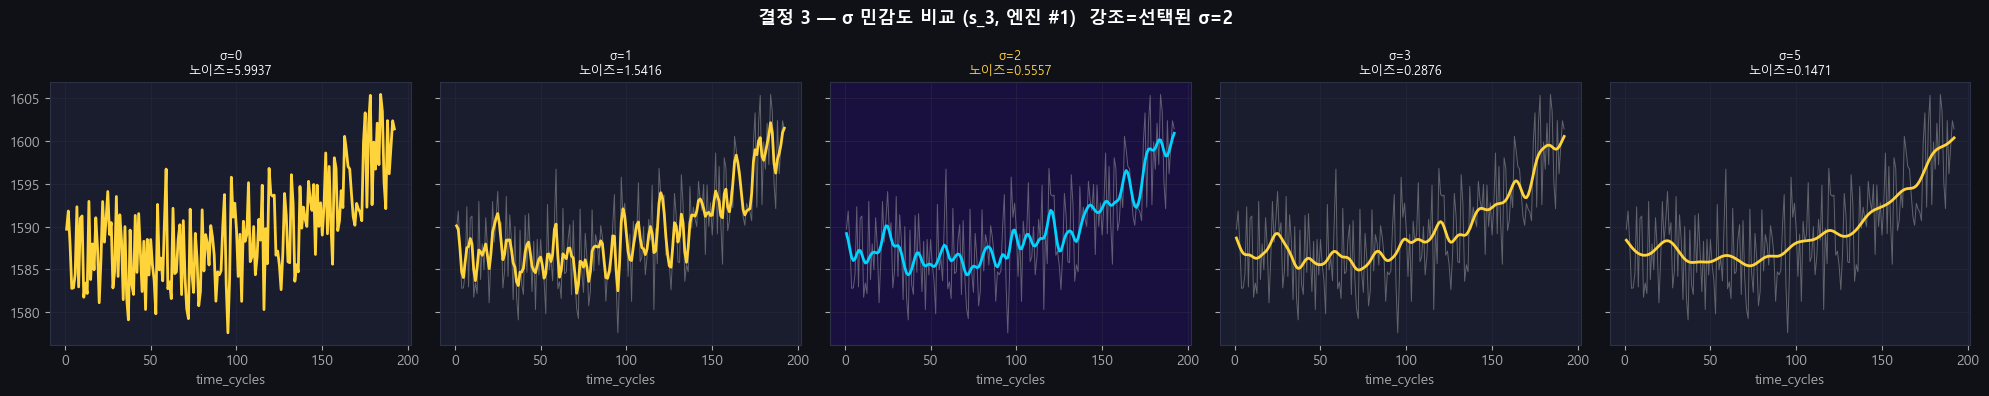

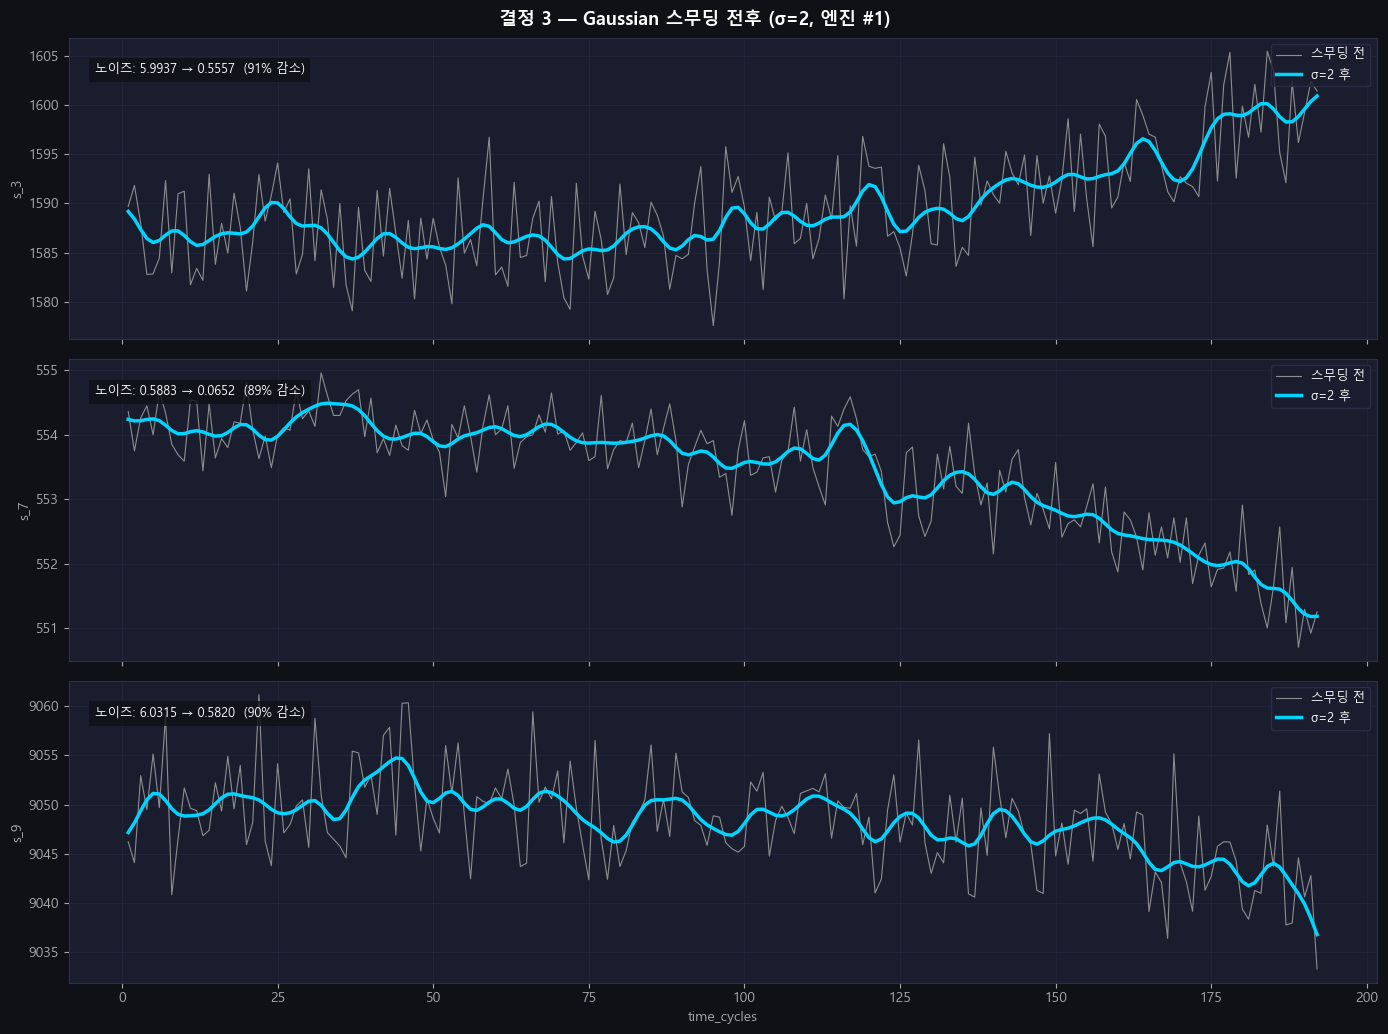

✅ 결정 3 완료  (σ=2, mode=nearest)


In [15]:
def apply_gaussian(df, features, sigma=GAUSS_SIGMA):
    df = df.copy().sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
    df[features] = df[features].astype(np.float32)
    for uid in df['unit_nr'].unique():
        mask = df['unit_nr'] == uid
        for col in features:
            arr = df.loc[mask, col].to_numpy(dtype=np.float32)
            df.loc[mask, col] = gaussian_filter1d(arr, sigma=sigma, mode='nearest')
    return df

train_s3 = apply_gaussian(train_s2, USEFUL_SENSORS)
test_s3  = apply_gaussian(test_s2,  USEFUL_SENSORS)

# σ 민감도 (엔진 #1, 대표 센서)
unit1_raw = train_s2[train_s2['unit_nr']==1].sort_values('time_cycles')
s_ex = 's_3' if 's_3' in USEFUL_SENSORS else USEFUL_SENSORS[0]
sigmas = [0, 1, 2, 3, 5]

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle(f'결정 3 — σ 민감도 비교 ({s_ex}, 엔진 #1)  강조=선택된 σ=2', fontsize=13, fontweight='bold')

for ax, sig in zip(axes, sigmas):
    y_raw = unit1_raw[s_ex].values
    y_f   = gaussian_filter1d(y_raw, sigma=sig, mode='nearest') if sig>0 else y_raw
    noise = np.std(np.diff(y_f))
    ax.plot(unit1_raw['time_cycles'], y_raw, color=GRAY, alpha=0.5, lw=0.7, label='원본')
    ax.plot(unit1_raw['time_cycles'], y_f,   color=C[0] if sig==GAUSS_SIGMA else C[3], lw=2)
    ax.set_title(f'σ={sig}\n노이즈={noise:.4f}',
                 color='#ffd43b' if sig==GAUSS_SIGMA else WHITE, fontsize=9)
    if sig==GAUSS_SIGMA: ax.patch.set_facecolor('#1a1040')
    ax.set_xlabel('time_cycles')

plt.tight_layout(); plt.show()

# 전후 비교 (3개 센서)
show3 = [s for s in ['s_3','s_7','s_9'] if s in USEFUL_SENSORS]
if len(show3) < 2: show3 = USEFUL_SENSORS[:3]

unit1_before = train_s2[train_s2['unit_nr']==1].sort_values('time_cycles')
unit1_after  = train_s3[train_s3['unit_nr']==1].sort_values('time_cycles')

fig, axes = plt.subplots(len(show3), 1, figsize=(14, 3.5*len(show3)), sharex=True)
if len(show3)==1: axes=[axes]
fig.suptitle(f'결정 3 — Gaussian 스무딩 전후 (σ={GAUSS_SIGMA}, 엔진 #1)', fontsize=13, fontweight='bold')

for ax, s in zip(axes, show3):
    ax.plot(unit1_before['time_cycles'], unit1_before[s], color=GRAY, lw=0.8, alpha=0.8, label='스무딩 전')
    ax.plot(unit1_after['time_cycles'],  unit1_after[s],  color=C[0], lw=2.5,             label=f'σ={GAUSS_SIGMA} 후')
    nb = np.std(np.diff(unit1_before[s].values))
    na = np.std(np.diff(unit1_after[s].values))
    pct = (1-na/nb)*100 if nb>0 else 0
    ax.text(0.02, 0.88, f'노이즈: {nb:.4f} → {na:.4f}  ({pct:.0f}% 감소)',
            transform=ax.transAxes, fontsize=9, bbox=dict(facecolor=BG, alpha=0.8, edgecolor='none'))
    ax.set_ylabel(s); ax.legend(fontsize=9, loc='upper right')

axes[-1].set_xlabel('time_cycles')
plt.tight_layout(); plt.show()
print(f'✅ 결정 3 완료  (σ={GAUSS_SIGMA}, mode=nearest)')


## 6. 결정 4 — Validation 분할 (unit 기준 80:20)

**공통 전처리(상수 제거 → RUL cap → Gaussian)가 끝난 `train_s3` 기준으로 분리.**  
파생변수(ML) 또는 슬라이딩 윈도우(DL)는 **정규화 이후** 각 분기에서 독립적으로 생성한다.

> ⚠️ 같은 엔진이 sub-train / validation에 동시에 들어가지 않도록 **unit 단위** 분리


In [16]:
# ── unit 기준 분리 ────────────────────────────────────────────
VALID_RATIO = 0.2

units          = np.sort(train_s3['unit_nr'].unique())
n_valid_units  = max(1, int(np.ceil(len(units) * VALID_RATIO)))
valid_units    = units[-n_valid_units:]
subtrain_units = units[:-n_valid_units]

subtrain_common = train_s3[train_s3['unit_nr'].isin(subtrain_units)].copy().reset_index(drop=True)
valid_common    = train_s3[train_s3['unit_nr'].isin(valid_units)].copy().reset_index(drop=True)
test_common     = test_s3.copy()

print('=== 결정 4 — Validation 분할 완료 ===')
print(f'전체 train 엔진 수 : {len(units)}대')
print(f'sub-train 엔진 수  : {len(subtrain_units)}대  unit {subtrain_units[0]}~{subtrain_units[-1]}')
print(f'valid 엔진 수      : {len(valid_units)}대  unit {valid_units[0]}~{valid_units[-1]}')
print(f'sub-train shape    : {subtrain_common.shape}')
print(f'valid shape        : {valid_common.shape}')
print(f'test shape         : {test_common.shape}')

split_summary = pd.DataFrame({
    '구분'           : ['Sub-train', 'Validation', 'Test'],
    '행 수'          : [len(subtrain_common), len(valid_common), len(test_common)],
    '엔진 수'        : [subtrain_common['unit_nr'].nunique(),
                        valid_common['unit_nr'].nunique(),
                        test_common['unit_nr'].nunique()],
    '피처 수(공통)'  : [len(USEFUL_SENSORS)] * 3,
    'RUL 포함'       : ['예', '예', '아니오'],
})
display(split_summary)


=== 결정 4 — Validation 분할 완료 ===
전체 train 엔진 수 : 100대
sub-train 엔진 수  : 80대  unit 1~80
valid 엔진 수      : 20대  unit 81~100
sub-train shape    : (16138, 21)
valid shape        : (4493, 21)
test shape         : (13096, 19)


,구분,행 수,엔진 수,피처 수(공통),RUL 포함
0,Sub-train,16138,80,14,예
1,Validation,4493,20,14,예
2,Test,13096,100,14,아니오


## 7. 결정 5 — MinMax 정규화 (sub-train 기준 fit)

**fit은 `sub-train`에서만** — validation·test는 동일 scaler로 transform (데이터 누수 방지).  
정규화 대상: **유용 센서 컬럼** (`USEFUL_SENSORS`) — ML/DL 파생변수는 정규화 후 생성.


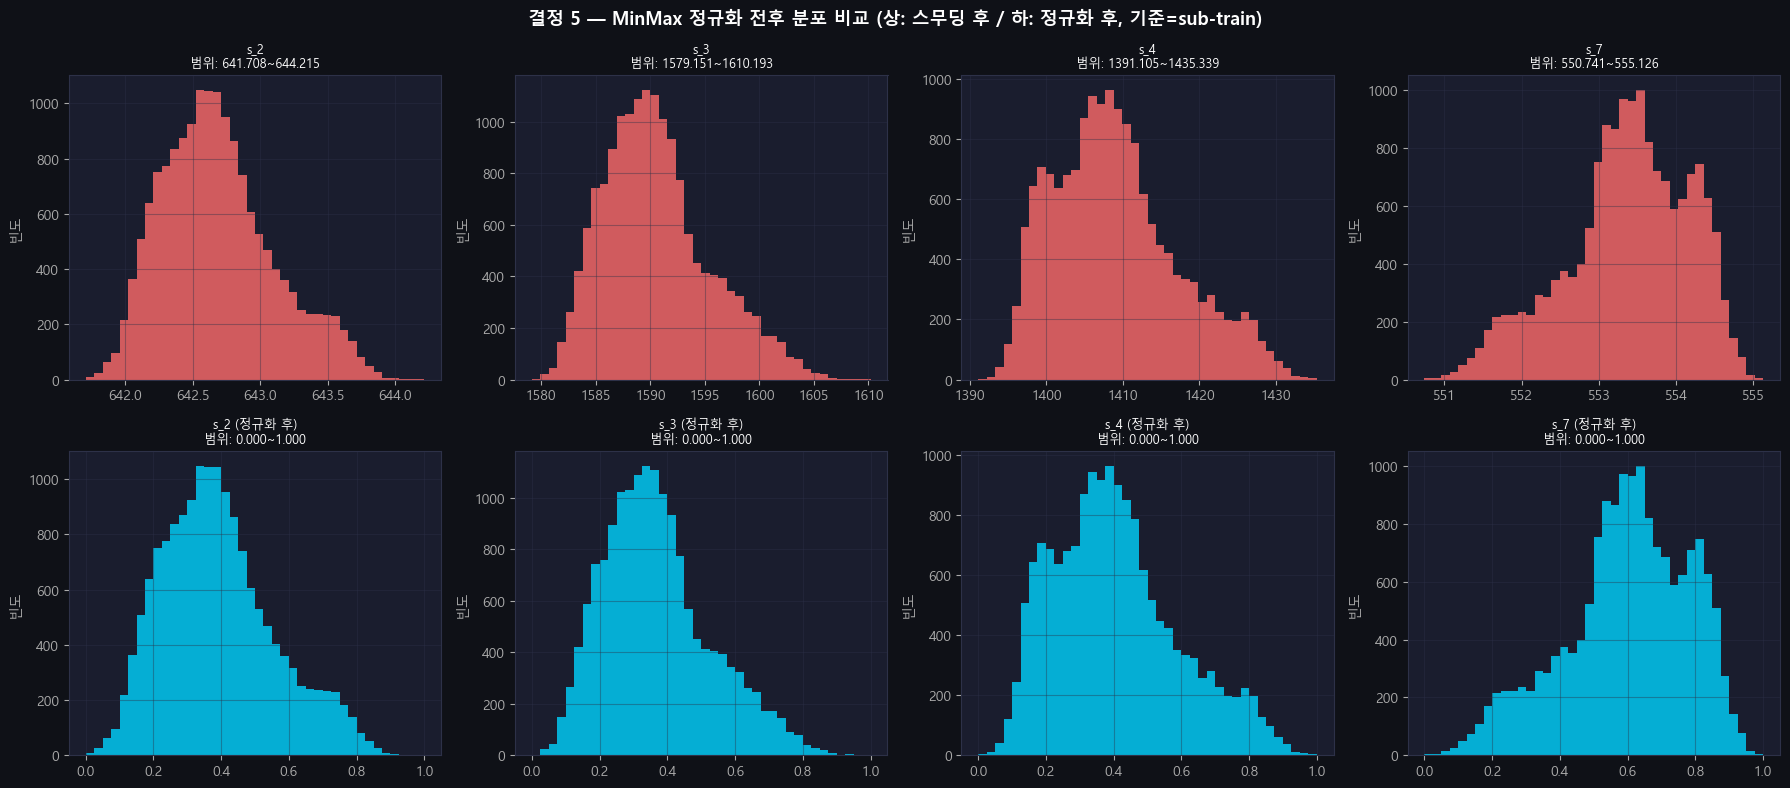

--- sub-train 기준 정규화 전후 범위 (USEFUL_SENSORS) ---


,전_min,전_max,후_min,후_max
s_2,641.708191,644.214722,0.0,1.0
s_3,1579.150879,1610.192871,0.0,1.0
s_4,1391.104858,1435.338623,0.0,1.0
s_7,550.741089,555.126404,0.0,1.0
s_8,2387.960205,2388.467285,0.0,1.0
s_9,9027.010742,9235.208984,0.0,1.0
s_11,47.029999,48.379200,0.0,1.0
s_12,519.109802,522.842102,0.0,1.0
s_13,2387.964844,2388.457031,0.0,1.0
s_14,8103.128906,8288.884766,0.0,1.0



✅ 결정 5 완료  |  sub-train: 0.0000~1.0000
   Validation : -0.0353~1.0027
   Test       : -0.0976~1.0112


In [17]:
from sklearn.preprocessing import MinMaxScaler

# ── 정규화 전 범위 기록 ────────────────────────────────────────
before_min = subtrain_common[USEFUL_SENSORS].min()
before_max = subtrain_common[USEFUL_SENSORS].max()

scaler = MinMaxScaler()
scaler.fit(subtrain_common[USEFUL_SENSORS])          # fit: sub-train만

subtrain_s4 = subtrain_common.copy()
valid_s4    = valid_common.copy()
test_s4     = test_common.copy()

subtrain_s4[USEFUL_SENSORS] = scaler.transform(subtrain_common[USEFUL_SENSORS])
valid_s4[USEFUL_SENSORS]    = scaler.transform(valid_common[USEFUL_SENSORS])
test_s4[USEFUL_SENSORS]     = scaler.transform(test_common[USEFUL_SENSORS])

# 전체 train(검증용) — 동일 scaler로 변환
train_s4 = train_s3.copy()
train_s4[USEFUL_SENSORS] = scaler.transform(train_s3[USEFUL_SENSORS])

# ── 전후 비교 시각화 (대표 4개 센서) ─────────────────────────────
show4 = USEFUL_SENSORS[:4]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('결정 5 — MinMax 정규화 전후 분포 비교 (상: 스무딩 후 / 하: 정규화 후, 기준=sub-train)',
             fontsize=13, fontweight='bold')

for col, s in enumerate(show4):
    b = subtrain_common[s];  a = subtrain_s4[s]
    axes[0, col].hist(b, bins=40, color=C[1], alpha=0.8, edgecolor='none')
    axes[0, col].set_title(f'{s}\n범위: {b.min():.3f}~{b.max():.3f}', fontsize=9)
    axes[0, col].set_ylabel('빈도')
    axes[1, col].hist(a, bins=40, color=C[0], alpha=0.8, edgecolor='none')
    axes[1, col].set_title(f'{s} (정규화 후)\n범위: {a.min():.3f}~{a.max():.3f}', fontsize=9)
    axes[1, col].set_ylabel('빈도')
plt.tight_layout(); plt.show()

# ── 범위 요약 ─────────────────────────────────────────────────
range_df = pd.DataFrame({
    '전_min': before_min, '전_max': before_max,
    '후_min': subtrain_s4[USEFUL_SENSORS].min(),
    '후_max': subtrain_s4[USEFUL_SENSORS].max(),
})
print('--- sub-train 기준 정규화 전후 범위 (USEFUL_SENSORS) ---')
display(range_df.round(4))
print(f'\n✅ 결정 5 완료  |  sub-train: {subtrain_s4[USEFUL_SENSORS].min().min():.4f}~{subtrain_s4[USEFUL_SENSORS].max().max():.4f}')
print(f'   Validation : {valid_s4[USEFUL_SENSORS].min().min():.4f}~{valid_s4[USEFUL_SENSORS].max().max():.4f}')
print(f'   Test       : {test_s4[USEFUL_SENSORS].min().min():.4f}~{test_s4[USEFUL_SENSORS].max().max():.4f}')


## 8. [ML 전용] 시계열 파생변수 생성 (정규화 후 적용)

정규화된 센서값을 기준으로 **각 split 내에서 독립적으로** 파생변수 생성 → 누수 없음.

| 유형 | 변수 | 목적 |
|---|---|---|
| `lag` | 1, 3, 5 | 단기 과거 상태 |
| `diff` | 1 | 변화량 |
| `rolling mean` | 3, 5 | 단기 추세 |
| `rolling std` | 3, 5 | 변동성 |
| `EMA` | 5 | 최근값 가중 추세 |

> 결측 보완: 각 엔진 내부에서 `bfill → ffill → 0` 순서 적용


In [18]:
def add_temporal_features(
    df, sensors,
    lags=TEMPORAL_LAGS, diffs=TEMPORAL_DIFFS,
    rolls=TEMPORAL_ROLLS, roll_stds=TEMPORAL_ROLL_STDS, emas=TEMPORAL_EMAS
):
    df = df.copy().sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
    created = []
    for s in sensors:
        grp = df.groupby('unit_nr', sort=False)[s]
        for lag in lags:
            col = f'{s}_lag{lag}'; df[col] = grp.shift(lag); created.append(col)
        for d in diffs:
            col = f'{s}_diff{d}'; df[col] = grp.diff(d); created.append(col)
        for r in rolls:
            col = f'{s}_roll{r}'
            df[col] = grp.transform(lambda x: x.rolling(r, min_periods=1).mean()); created.append(col)
        for r in roll_stds:
            col = f'{s}_roll_std{r}'
            df[col] = grp.transform(lambda x: x.rolling(r, min_periods=1).std()); created.append(col)
        for e in emas:
            col = f'{s}_ema{e}'
            df[col] = grp.transform(lambda x: x.ewm(span=e, adjust=False).mean()); created.append(col)
    # 결측 보완 (엔진 내부에서만)
    df[created] = df.groupby('unit_nr', sort=False)[created].transform(
        lambda x: x.bfill().ffill())
    df[created] = df[created].fillna(0.0)
    return df, created

# ── 각 split에 독립 적용 ──────────────────────────────────────
subtrain_ml, TEMPORAL_FEATURES = add_temporal_features(subtrain_s4, USEFUL_SENSORS)
valid_ml,    _                 = add_temporal_features(valid_s4,    USEFUL_SENSORS)
test_ml,     _                 = add_temporal_features(test_s4,     USEFUL_SENSORS)
ML_FEATURES = USEFUL_SENSORS + TEMPORAL_FEATURES

print('=== [ML] 시계열 파생변수 생성 완료 ===')
print(f'원본 센서 수    : {len(USEFUL_SENSORS)}개')
print(f'파생변수 수     : {len(TEMPORAL_FEATURES)}개')
print(f'ML 입력 변수 수 : {len(ML_FEATURES)}개')
print(f'  lag {TEMPORAL_LAGS}  diff {TEMPORAL_DIFFS}  roll {TEMPORAL_ROLLS}  roll_std {TEMPORAL_ROLL_STDS}  ema {TEMPORAL_EMAS}')
print()
print(f'subtrain_ml : {subtrain_ml.shape}  |  결측: {subtrain_ml[ML_FEATURES].isnull().sum().sum()}')
print(f'valid_ml    : {valid_ml.shape}    |  결측: {valid_ml[ML_FEATURES].isnull().sum().sum()}')
print(f'test_ml     : {test_ml.shape}     |  결측: {test_ml[ML_FEATURES].isnull().sum().sum()}')

# ── 대표 센서 파생변수 미리보기 ───────────────────────────────────
demo_s = 's_3' if 's_3' in USEFUL_SENSORS else USEFUL_SENSORS[0]
demo_cols = [demo_s] + [c for c in TEMPORAL_FEATURES if c.startswith(f'{demo_s}_')][:8]
print(f'\n파생변수 미리보기 ({demo_s}, sub-train 엔진#1):')
display(subtrain_ml[subtrain_ml['unit_nr']==subtrain_units[0]]
        [['unit_nr','time_cycles']+demo_cols].head(8))


=== [ML] 시계열 파생변수 생성 완료 ===
원본 센서 수    : 14개
파생변수 수     : 126개
ML 입력 변수 수 : 140개
  lag [1, 3, 5]  diff [1]  roll [3, 5]  roll_std [3, 5]  ema [5]

subtrain_ml : (16138, 147)  |  결측: 0
valid_ml    : (4493, 147)    |  결측: 0
test_ml     : (13096, 145)     |  결측: 0

파생변수 미리보기 (s_3, sub-train 엔진#1):


,unit_nr,time_cycles,s_3,s_3_lag1,s_3_lag3,s_3_lag5,s_3_diff1,s_3_roll3,s_3_roll5,s_3_roll_std3,s_3_roll_std5
0,1,1,0.323437,0.323437,0.323437,0.323437,-0.025169,0.323437,0.323437,0.017797,0.017797
1,1,2,0.298267,0.323437,0.323437,0.323437,-0.025169,0.310852,0.310852,0.017797,0.017797
2,1,3,0.264542,0.298267,0.323437,0.323437,-0.033726,0.295415,0.295415,0.029551,0.029551
3,1,4,0.234715,0.264542,0.323437,0.323437,-0.029827,0.265841,0.280240,0.031796,0.038773
4,1,5,0.221756,0.234715,0.298267,0.323437,-0.012959,0.240337,0.268543,0.021940,0.042562
5,1,6,0.228531,0.221756,0.264542,0.323437,0.006775,0.228334,0.249562,0.006482,0.031751
6,1,7,0.245796,0.228531,0.234715,0.298267,0.017265,0.232028,0.239068,0.012396,0.016762
7,1,8,0.259598,0.245796,0.221756,0.264542,0.013802,0.244642,0.238079,0.015566,0.014929


## 9. [DL 전용] 슬라이딩 윈도우 생성 → Long Format CSV 저장

정규화된 `USEFUL_SENSORS`를 슬라이딩 윈도우로 변환 후 **Long Format CSV**로 저장.  
LSTM·CNN·Transformer 등 시계열 모델에 활용 가능.

| 파라미터 | 값 | 설명 |
|---|---|---|
| `WINDOW_SIZE` | 30 | 한 샘플당 연속 사이클 수 |
| `STEP` | 1 | 슬라이딩 간격 (stride) |
| 타깃 | 마지막 timestep의 RUL | many-to-one 예측 |

**Long Format 구조 (방식 B):**

```
sample_id | timestep | s_1 | s_2 | ... | s_14 | RUL
    0     |    0     | ... | ... | ... | ...  | 125
    0     |    1     | ... | ... | ... | ...  | 125
   ...
    0     |   29     | ... | ... | ... | ...  | 125   ← 이 행의 RUL이 예측 타깃
    1     |    0     | ... | ...
```

> - `sample_id`: 윈도우 단위 고유 ID  
> - `timestep`: 윈도우 내 위치 (0 ~ WINDOW_SIZE-1)  
> - `RUL`: 해당 샘플의 타깃값 (마지막 timestep 기준, 모든 행에 동일하게 기재)  
> - **Test**: 엔진별 마지막 30사이클 → 1 샘플. 시계열이 짧으면 앞쪽 zero-pad


=== [DL] 슬라이딩 윈도우 생성 완료 ===
WINDOW_SIZE=30  STEP=1  DL 피처 수=14
X_subtrain_dl : (13818, 30, 14)  y: (13818,)
X_valid_dl    : (3913, 30, 14)    y: (3913,)
X_test_dl     : (100, 30, 14)     y: (100,)

Long Format 변환 중... (행 수 = 샘플 수 × WINDOW_SIZE)
dl_subtrain_long : (414540, 17)  (샘플 13818개 × 30 = 414540행)
dl_valid_long    : (117390, 17)
dl_test_long     : (3000, 17)  (엔진 100개 × 30 = 3000행)

dl_subtrain_long 상위 5행 (sample_id=0):


,sample_id,timestep,s_2,s_3,s_4,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21,RUL
0,0,0,0.114655,0.323437,0.239313,0.797638,0.200195,0.096710,0.288395,0.762344,0.142090,0.178055,0.318676,0.207260,0.791080,0.820499,125.0
1,0,1,0.153900,0.298267,0.250179,0.792168,0.204590,0.101440,0.255997,0.802551,0.154297,0.172237,0.304970,0.196136,0.764874,0.804008,125.0
2,0,2,0.190887,0.264542,0.256216,0.792892,0.207031,0.107342,0.218735,0.834030,0.162598,0.167377,0.286991,0.191971,0.740726,0.787354,125.0
3,0,3,0.218109,0.234715,0.252851,0.797440,0.200684,0.112759,0.187069,0.846680,0.164551,0.163830,0.270885,0.195488,0.728054,0.774170,125.0
4,0,4,0.233643,0.221756,0.238979,0.799484,0.185059,0.115856,0.168262,0.841095,0.160156,0.160839,0.259998,0.201149,0.731430,0.765362,125.0



dl_subtrain_long 구조:
  컬럼 수 : 17개  (sample_id + timestep + 14개 센서 + RUL)
  RUL 범위: 0 ~ 125

복원 방법:
  grp = dl_subtrain_long.groupby("sample_id")
  X   = np.stack([grp.get_group(i)[DL_FEATURES].values for i in range(n)])
  y   = dl_subtrain_long.groupby("sample_id")["RUL"].last().values


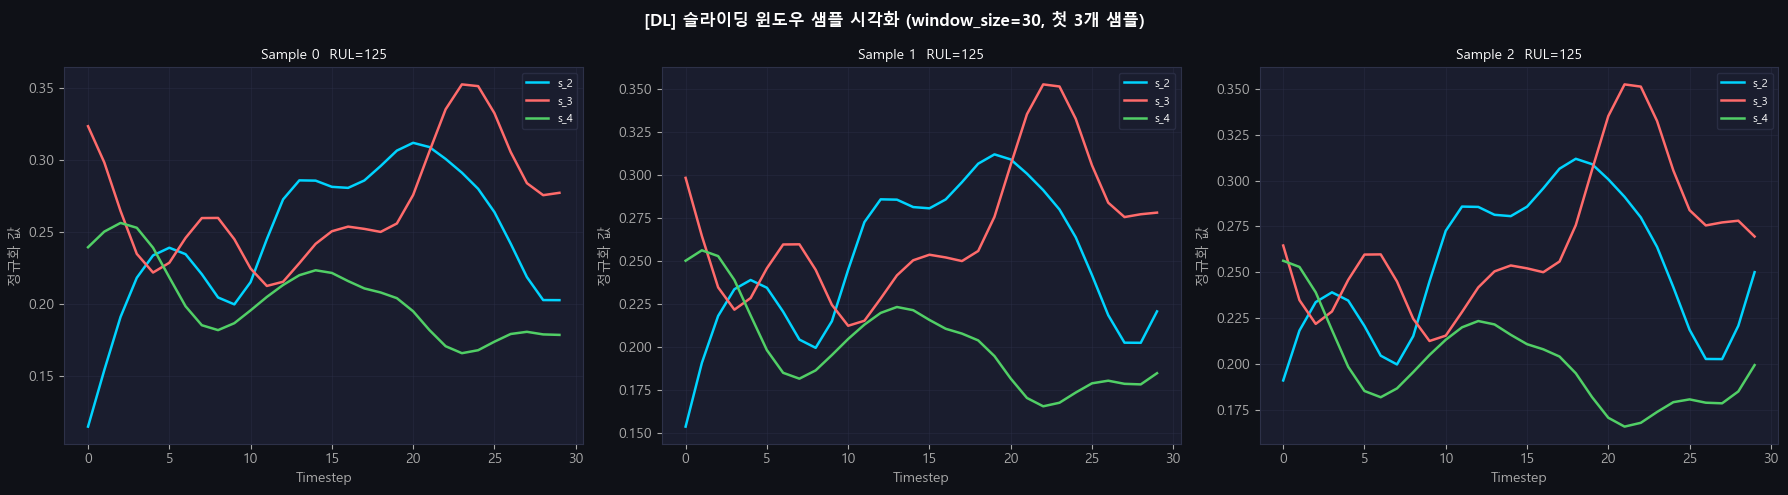

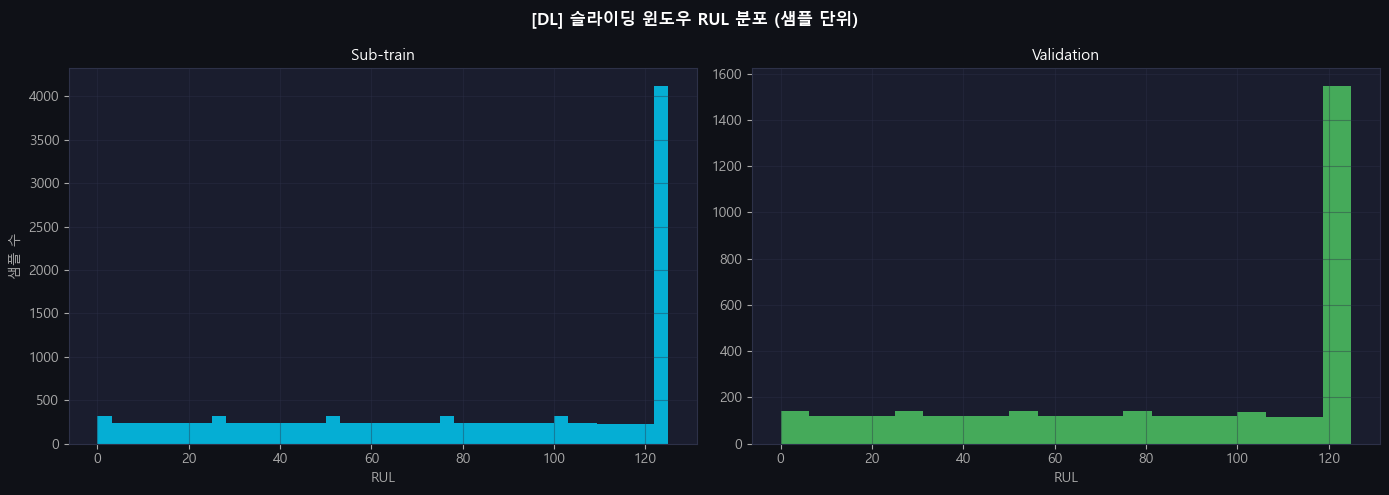

In [19]:
WINDOW_SIZE = 30
STEP        = 1
DL_FEATURES = USEFUL_SENSORS       # 원본 정규화 센서만 사용 (파생변수 불필요)

# ─────────────────────────────────────────────────────────────────
def create_sliding_windows(df, feature_cols, target_col=None,
                           window_size=WINDOW_SIZE, step=STEP):
    """3D 텐서 (n_samples, window_size, n_features) 반환"""
    X_list, y_list = [], []
    for uid in np.sort(df['unit_nr'].unique()):
        udf  = df[df['unit_nr'] == uid].sort_values('time_cycles')
        data = udf[feature_cols].values.astype(np.float32)
        tgt  = udf[target_col].values if target_col else None
        n    = len(data)
        for start in range(0, n - window_size + 1, step):
            end = start + window_size
            X_list.append(data[start:end])
            if tgt is not None:
                y_list.append(tgt[end - 1])   # 마지막 timestep의 RUL
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32) if y_list else None
    return X, y


def create_test_windows(df, feature_cols, rul_series, window_size=WINDOW_SIZE):
    """Test: 엔진별 마지막 window_size 사이클 → 1샘플씩"""
    X_list, y_list = [], []
    for i, uid in enumerate(np.sort(df['unit_nr'].unique())):
        udf  = df[df['unit_nr'] == uid].sort_values('time_cycles')
        data = udf[feature_cols].values.astype(np.float32)
        if len(data) >= window_size:
            X_list.append(data[-window_size:])
        else:
            pad = np.zeros((window_size - len(data), len(feature_cols)), dtype=np.float32)
            X_list.append(np.vstack([pad, data]))
        y_list.append(float(rul_series.iloc[i]))
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


def windows_to_long_df(X, y, feature_cols):
    """
    3D 텐서 → Long Format DataFrame

    Parameters
    ----------
    X : ndarray (n_samples, window_size, n_features)
    y : ndarray (n_samples,) — 각 샘플의 RUL 타깃
    feature_cols : list — 센서 이름 목록

    Returns
    -------
    DataFrame 컬럼: sample_id | timestep | s_1 ... s_14 | RUL
    """
    n_samples, win_size, n_feat = X.shape
    rows = []
    for sid in range(n_samples):
        rul_val = float(y[sid])
        for t in range(win_size):
            row = {'sample_id': sid, 'timestep': t}
            for fi, fname in enumerate(feature_cols):
                row[fname] = float(X[sid, t, fi])
            row['RUL'] = rul_val          # 모든 행에 동일 타깃 기재
            rows.append(row)
    col_order = ['sample_id', 'timestep'] + list(feature_cols) + ['RUL']
    return pd.DataFrame(rows, columns=col_order)


# ── 슬라이딩 윈도우 생성 ──────────────────────────────────────────
X_subtrain_dl, y_subtrain_dl = create_sliding_windows(subtrain_s4, DL_FEATURES, 'RUL')
X_valid_dl,    y_valid_dl    = create_sliding_windows(valid_s4,    DL_FEATURES, 'RUL')
X_test_dl,     y_test_dl     = create_test_windows(  test_s4,     DL_FEATURES, rul_df['RUL'])

print('=== [DL] 슬라이딩 윈도우 생성 완료 ===')
print(f'WINDOW_SIZE={WINDOW_SIZE}  STEP={STEP}  DL 피처 수={len(DL_FEATURES)}')
print(f'X_subtrain_dl : {X_subtrain_dl.shape}  y: {y_subtrain_dl.shape}')
print(f'X_valid_dl    : {X_valid_dl.shape}    y: {y_valid_dl.shape}')
print(f'X_test_dl     : {X_test_dl.shape}     y: {y_test_dl.shape}')
print()

# ── Long Format 변환 ──────────────────────────────────────────────
print('Long Format 변환 중... (행 수 = 샘플 수 × WINDOW_SIZE)')
dl_subtrain_long = windows_to_long_df(X_subtrain_dl, y_subtrain_dl, DL_FEATURES)
dl_valid_long    = windows_to_long_df(X_valid_dl,    y_valid_dl,    DL_FEATURES)
dl_test_long     = windows_to_long_df(X_test_dl,     y_test_dl,     DL_FEATURES)

print(f'dl_subtrain_long : {dl_subtrain_long.shape}  '
      f'(샘플 {X_subtrain_dl.shape[0]}개 × {WINDOW_SIZE} = {X_subtrain_dl.shape[0]*WINDOW_SIZE}행)')
print(f'dl_valid_long    : {dl_valid_long.shape}')
print(f'dl_test_long     : {dl_test_long.shape}  (엔진 100개 × {WINDOW_SIZE} = {len(X_test_dl)*WINDOW_SIZE}행)')
print()
print('dl_subtrain_long 상위 5행 (sample_id=0):')
display(dl_subtrain_long.head(5))
print()
print('dl_subtrain_long 구조:')
print(f'  컬럼 수 : {dl_subtrain_long.shape[1]}개  '
      f'(sample_id + timestep + {len(DL_FEATURES)}개 센서 + RUL)')
print(f'  RUL 범위: {dl_subtrain_long["RUL"].min():.0f} ~ {dl_subtrain_long["RUL"].max():.0f}')
print()
print('복원 방법:')
print('  grp = dl_subtrain_long.groupby("sample_id")')
print('  X   = np.stack([grp.get_group(i)[DL_FEATURES].values for i in range(n)])')
print('  y   = dl_subtrain_long.groupby("sample_id")["RUL"].last().values')

# ── 샘플 시각화 ───────────────────────────────────────────────────
show_s = DL_FEATURES[:3]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'[DL] 슬라이딩 윈도우 샘플 시각화 (window_size={WINDOW_SIZE}, 첫 3개 샘플)',
             fontsize=12, fontweight='bold')
for ax, s_idx in zip(axes, range(3)):
    for fi, fname in enumerate(show_s):
        ax.plot(X_subtrain_dl[s_idx, :, DL_FEATURES.index(fname)],
                color=C[fi], lw=1.8, label=fname)
    ax.set_title(f'Sample {s_idx}  RUL={y_subtrain_dl[s_idx]:.0f}', fontsize=10)
    ax.set_xlabel('Timestep'); ax.set_ylabel('정규화 값'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# ── RUL 분포 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('[DL] 슬라이딩 윈도우 RUL 분포 (샘플 단위)', fontsize=12, fontweight='bold')
axes[0].hist(y_subtrain_dl, bins=40, color=C[0], alpha=0.8, edgecolor='none')
axes[0].set_title('Sub-train'); axes[0].set_xlabel('RUL'); axes[0].set_ylabel('샘플 수')
axes[1].hist(y_valid_dl, bins=20, color=C[2], alpha=0.8, edgecolor='none')
axes[1].set_title('Validation'); axes[1].set_xlabel('RUL')
plt.tight_layout(); plt.show()


---
## 10. 전처리 후 검증 — 공통 전처리 확인


### 10-1. 센서 간 상관관계 — 전처리 전후 비교


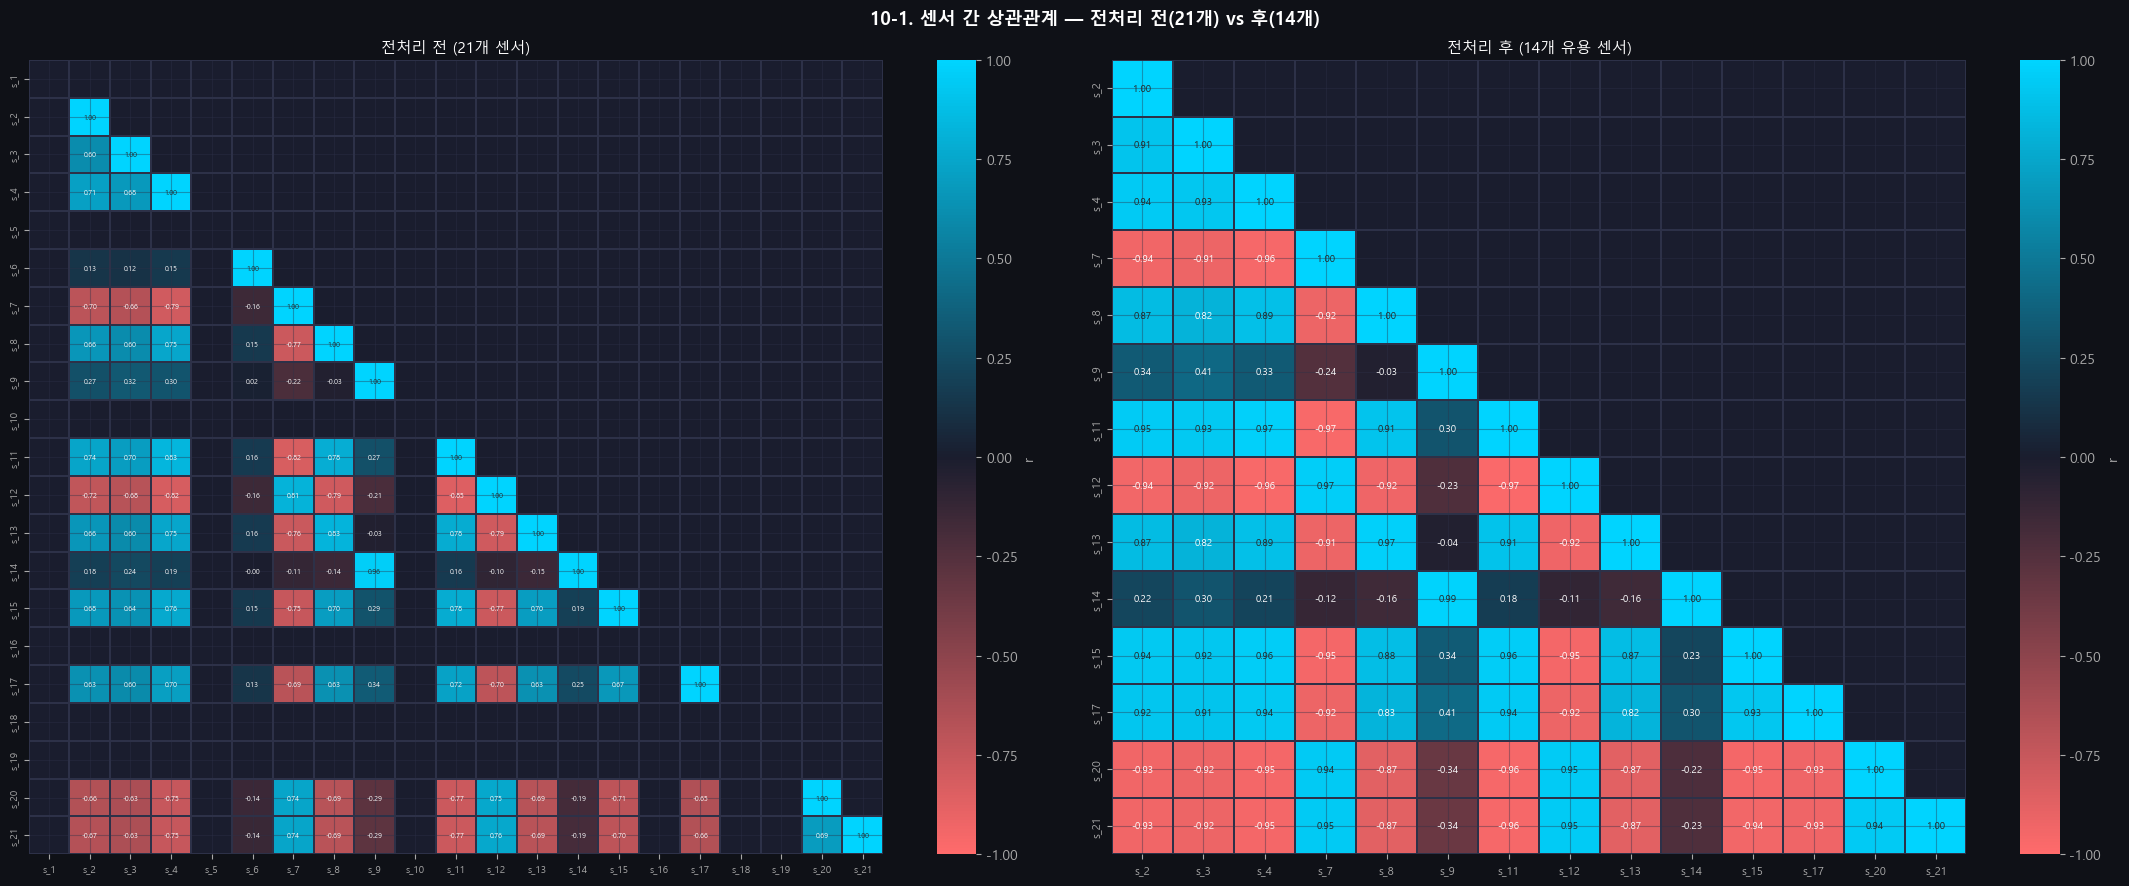

고상관 쌍(|r|>0.9): 전 1개 → 후 53개


In [20]:
corr_after = train_s4[USEFUL_SENSORS].corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle('10-1. 센서 간 상관관계 — 전처리 전(21개) vs 후(14개)', fontsize=13, fontweight='bold')

mask_b = np.triu(np.ones_like(corr_before, dtype=bool), k=1)
sns.heatmap(corr_before, ax=axes[0], mask=mask_b, cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size':5}, linewidths=0.3, linecolor=GRID,
            cbar_kws={'label':'r'})
axes[0].set_title('전처리 전 (21개 센서)', fontsize=11); axes[0].tick_params(labelsize=7)

mask_a = np.triu(np.ones_like(corr_after, dtype=bool), k=1)
sns.heatmap(corr_after, ax=axes[1], mask=mask_a, cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size':7}, linewidths=0.3, linecolor=GRID,
            cbar_kws={'label':'r'})
axes[1].set_title('전처리 후 (14개 유용 센서)', fontsize=11); axes[1].tick_params(labelsize=8)
plt.tight_layout(); plt.show()

pairs_after = [(USEFUL_SENSORS[i],USEFUL_SENSORS[j],round(corr_after.iloc[i,j],3))
               for i in range(len(USEFUL_SENSORS)) for j in range(i+1,len(USEFUL_SENSORS))
               if abs(corr_after.iloc[i,j])>0.9]
print(f'고상관 쌍(|r|>0.9): 전 {len(pairs)}개 → 후 {len(pairs_after)}개')


### 10-2. 센서 분포 전후 비교 (유용 센서 전체)


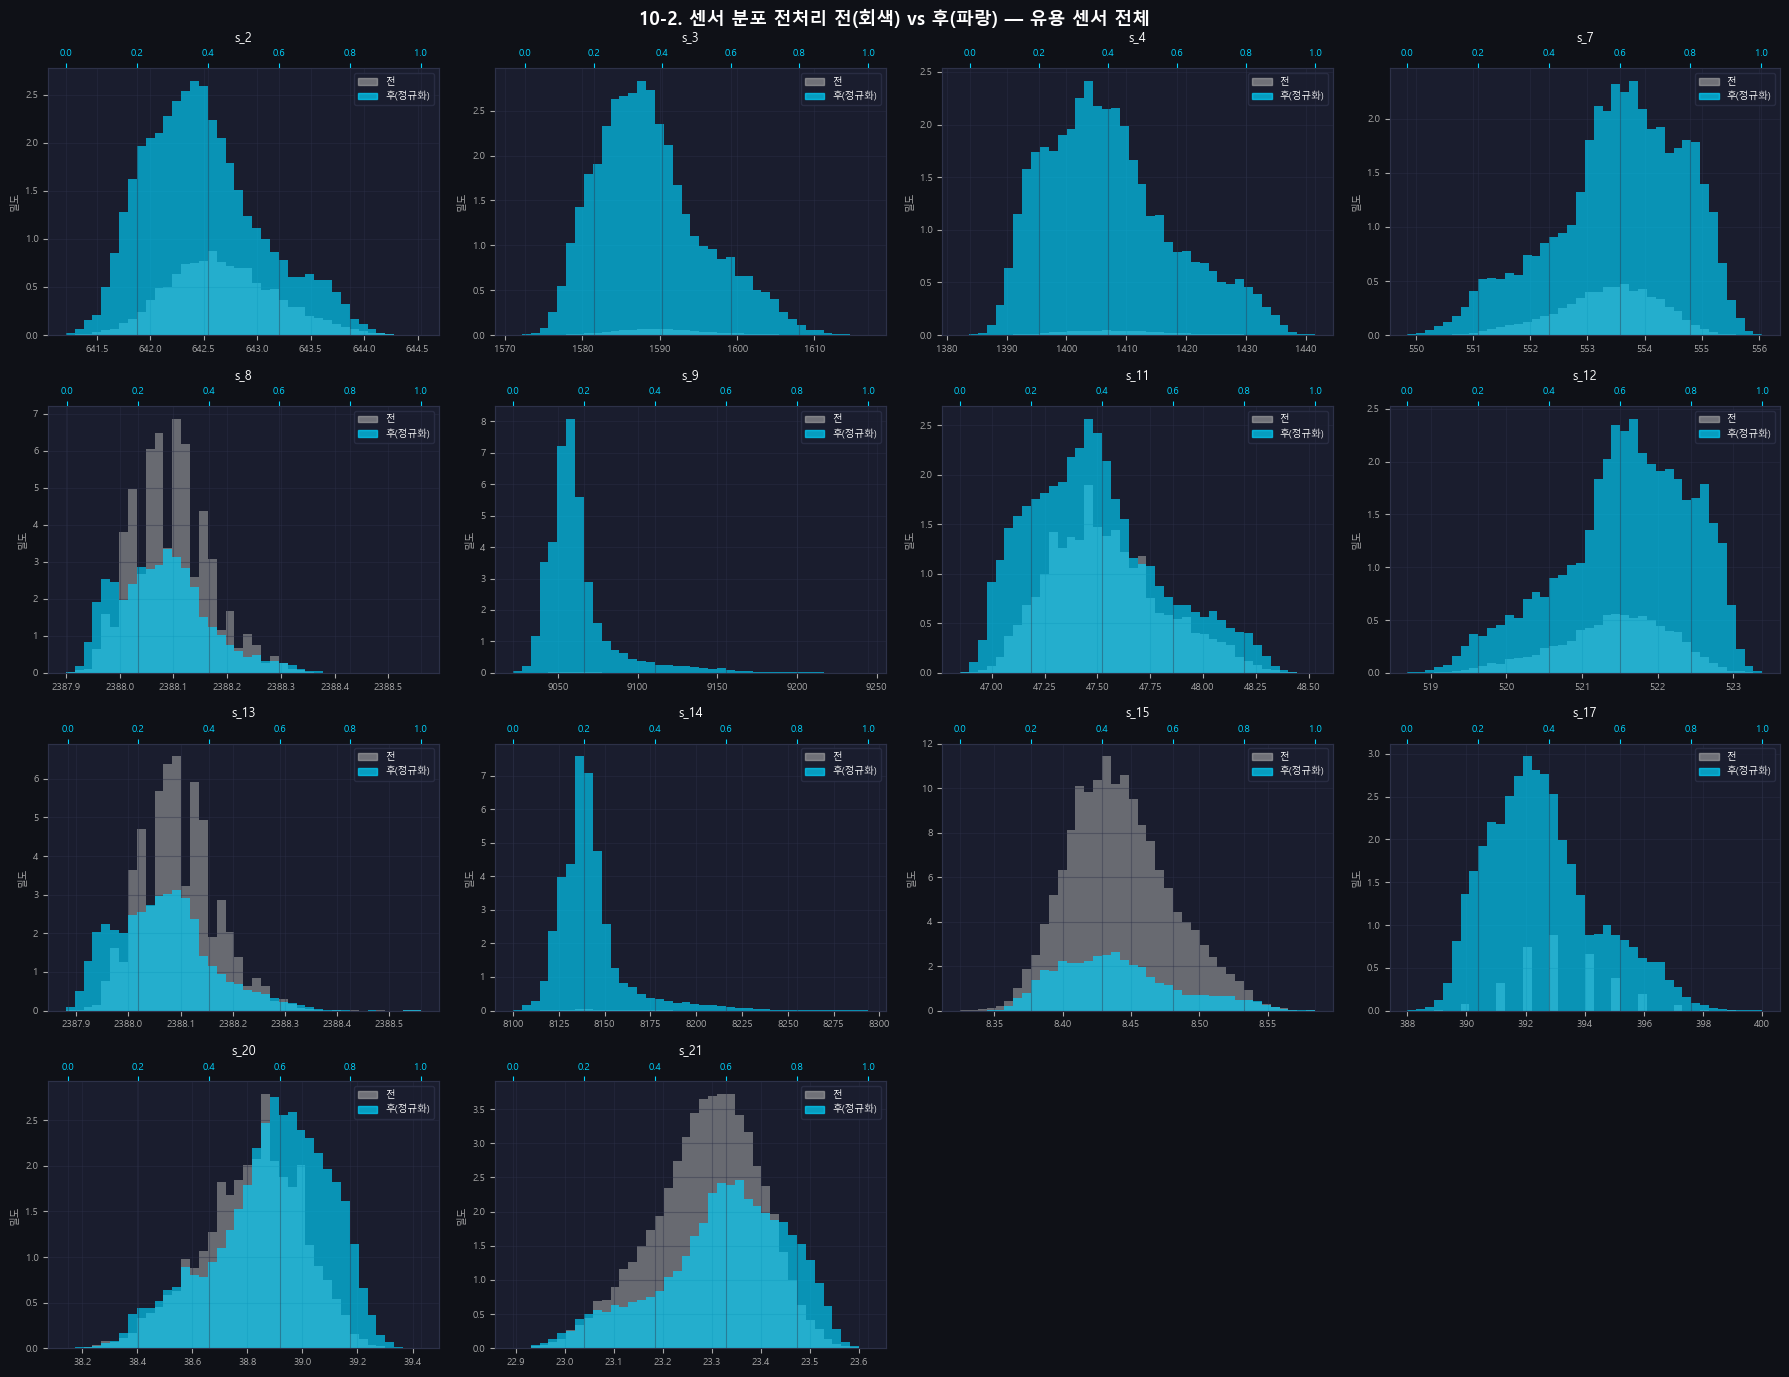

In [21]:
import matplotlib.patches as mpatches
n_cols = 4
n_rows = (len(USEFUL_SENSORS)+n_cols-1)//n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*3.5))
fig.suptitle('10-2. 센서 분포 전처리 전(회색) vs 후(파랑) — 유용 센서 전체', fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, USEFUL_SENSORS):
    before_data = train_s2[s]
    after_data  = train_s4[s]
    ax2 = ax.twiny()
    ax.hist(before_data,  bins=40, color=GRAY, alpha=0.55, density=True)
    ax2.hist(after_data, bins=40, color=C[0],  alpha=0.65, density=True)
    ax.set_title(f'{s}', fontsize=9); ax.set_ylabel('밀도', fontsize=7)
    ax.tick_params(labelsize=7); ax2.tick_params(labelsize=7, colors=C[0])
    handles = [mpatches.Patch(color=GRAY, alpha=0.6, label='전'),
               mpatches.Patch(color=C[0], alpha=0.7, label='후(정규화)')]
    ax.legend(handles=handles, fontsize=7, loc='upper right')
for ax in axes.flat[len(USEFUL_SENSORS):]: ax.set_visible(False)
plt.tight_layout(); plt.show()


### 10-3. Train vs Test 분포 비교 (전처리 후)


=== 10-3. Train vs Test 분포 비교 (KS 검정) ===


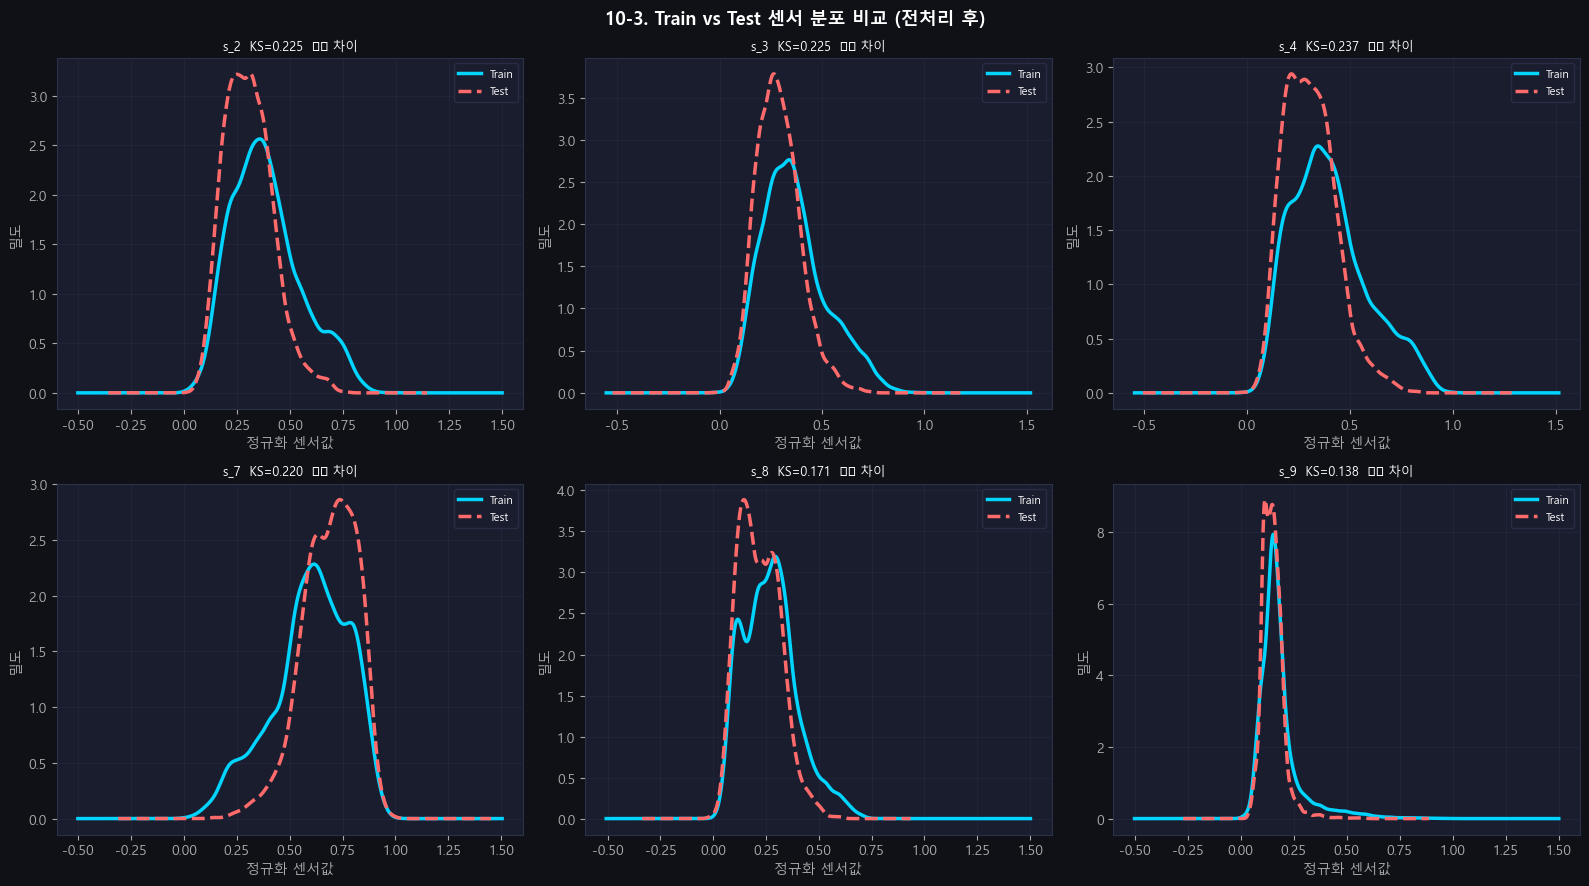

,KS통계량,p-value,판정
센서,,,
s_2,0.2251,0.0,⚠️ 차이
s_3,0.2248,0.0,⚠️ 차이
s_4,0.2369,0.0,⚠️ 차이
s_7,0.2201,0.0,⚠️ 차이
s_8,0.1711,0.0,⚠️ 차이
s_9,0.1384,0.0,⚠️ 차이


📌 Train=고장 전체기록(극단값 포함) / Test=고장 전 일부 → 분포 차이는 설계 특성


In [22]:
from scipy.stats import ks_2samp
print('=== 10-3. Train vs Test 분포 비교 (KS 검정) ===')
show6 = USEFUL_SENSORS[:6]; ks_rows = []
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('10-3. Train vs Test 센서 분포 비교 (전처리 후)', fontsize=13, fontweight='bold')
for ax, s in zip(axes.flat, show6):
    tr_v = train_s4[s].dropna(); te_v = test_s4[s].dropna()
    try: tr_v.plot.kde(ax=ax, color=C[0], lw=2.5, label='Train')
    except: pass
    try: te_v.plot.kde(ax=ax, color=C[1], lw=2.5, ls='--', label='Test')
    except: pass
    ks_stat, ks_p = ks_2samp(tr_v, te_v)
    verdict = '✅ 유사' if ks_p>0.05 else '⚠️ 차이'
    ks_rows.append({'센서':s,'KS통계량':round(ks_stat,4),'p-value':round(ks_p,4),'판정':verdict})
    ax.set_title(f'{s}  KS={ks_stat:.3f}  {verdict}', fontsize=9)
    ax.set_xlabel('정규화 센서값'); ax.set_ylabel('밀도'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
display(pd.DataFrame(ks_rows).set_index('센서'))
print('📌 Train=고장 전체기록(극단값 포함) / Test=고장 전 일부 → 분포 차이는 설계 특성')


### 10-4. 열화 트렌드 전후 비교 + RUL 상관계수 변화


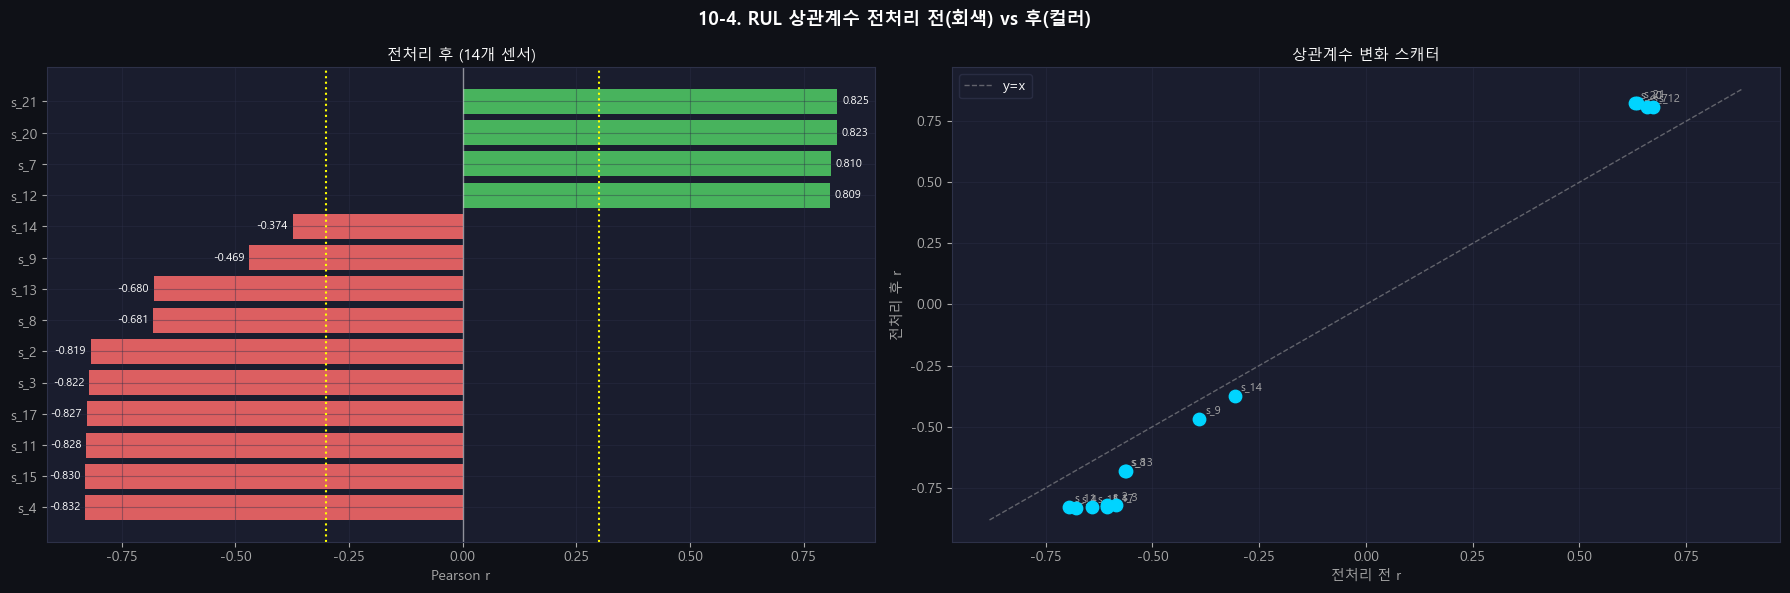

In [23]:
rul_corr_after = train_s4[USEFUL_SENSORS+['RUL']].corr()['RUL'][USEFUL_SENSORS].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('10-4. RUL 상관계수 전처리 전(회색) vs 후(컬러)', fontsize=13, fontweight='bold')

bc = [C[1] if v<0 else C[2] for v in rul_corr_after]
bars = axes[0].barh(rul_corr_after.index, rul_corr_after.values, color=bc, alpha=0.85)
axes[0].axvline(0, color='white', lw=1, alpha=0.5)
axes[0].axvline( 0.3, color='yellow', lw=1.5, ls=':')
axes[0].axvline(-0.3, color='yellow', lw=1.5, ls=':')
axes[0].set_title('전처리 후 (14개 센서)'); axes[0].set_xlabel('Pearson r')
for bar, val in zip(bars, rul_corr_after.values):
    axes[0].text(val+(0.01 if val>=0 else -0.01), bar.get_y()+bar.get_height()/2,
                 f'{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)

common_s = [s for s in USEFUL_SENSORS if s in rul_corr_before.index]
r_b = rul_corr_before[common_s]; r_a = rul_corr_after[common_s]
axes[1].scatter(r_b, r_a, color=C[0], s=80, zorder=5)
for s in common_s:
    axes[1].annotate(s, (r_b[s], r_a[s]), fontsize=8, color=GRAY, xytext=(4,4), textcoords='offset points')
lim = max(abs(r_b).max(), abs(r_a).max()) + 0.05
axes[1].plot([-lim,lim],[-lim,lim], color=GRAY, ls='--', lw=1, alpha=0.5, label='y=x')
axes[1].set_xlabel('전처리 전 r'); axes[1].set_ylabel('전처리 후 r')
axes[1].set_title('상관계수 변화 스캐터'); axes[1].legend()
plt.tight_layout(); plt.show()


### 10-5. [ML] 파생변수 다중공선성 확인 (|r| > 0.95)

> **목적:** ML 파생변수 간 거의 동일한 정보를 담는 쌍 탐지 — 모델 피처 중요도 확인 후 제거 결정


=== 10-5. ML 파생변수 다중공선성 확인 (sub-train, |r|>0.95) ===
분석 대상: ML_FEATURES 140개
|r|≥0.95 쌍: 1102개 / 전체 9730쌍


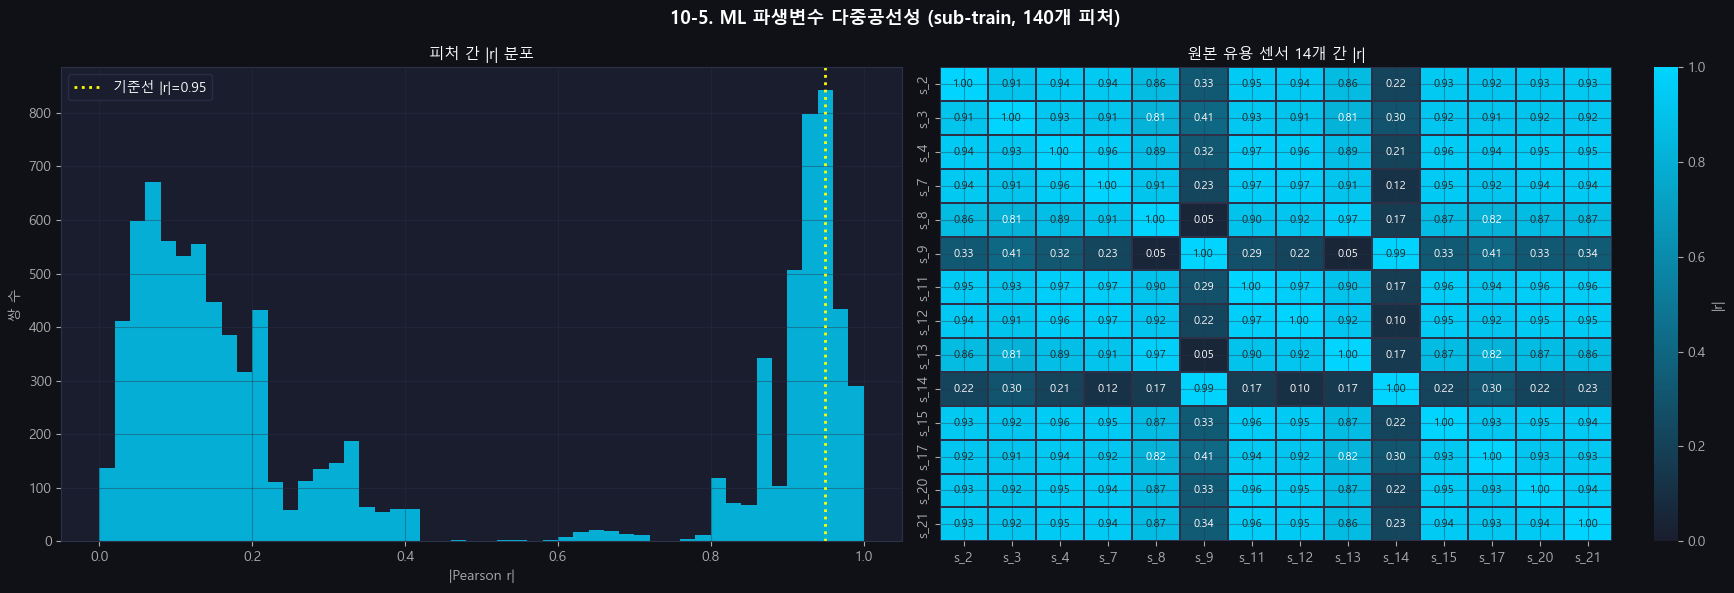


--- 상위 20 고상관 쌍 ---


,피처A,피처B,|r|
0,s_14_lag1,s_14_roll3,0.999990
1,s_9_lag1,s_9_roll3,0.999987
2,s_11_lag1,s_11_roll3,0.999940
3,s_14_roll5,s_14_ema5,0.999938
4,s_12_lag1,s_12_roll3,0.999928
5,s_8_lag1,s_8_roll3,0.999920
6,s_9_roll5,s_9_ema5,0.999919
7,s_13_lag1,s_13_roll3,0.999918
8,s_4_lag1,s_4_roll3,0.999911
9,s_7_lag1,s_7_roll3,0.999908


→ 실제 제거는 모델 피처 중요도 확인 후 결정 권장


In [24]:
print(f'=== 10-5. ML 파생변수 다중공선성 확인 (sub-train, |r|>0.95) ===')
print(f'분석 대상: ML_FEATURES {len(ML_FEATURES)}개')

corr_ml  = subtrain_ml[ML_FEATURES].corr().abs()
upper_ml = corr_ml.where(np.triu(np.ones(corr_ml.shape), k=1).astype(bool))
HIGH_THR = 0.95
high_pairs_ml = (upper_ml.stack().reset_index()
                 .rename(columns={'level_0':'피처A','level_1':'피처B',0:'|r|'})
                 .query('`|r|` >= @HIGH_THR')
                 .sort_values('|r|', ascending=False).reset_index(drop=True))

print(f'|r|≥{HIGH_THR} 쌍: {len(high_pairs_ml)}개 / 전체 {len(ML_FEATURES)*(len(ML_FEATURES)-1)//2}쌍')

from matplotlib.colors import LinearSegmentedColormap
cmap_mc = LinearSegmentedColormap.from_list('mc', ['#1a1d2e','#00d4ff'], N=256)
all_upper_vals = upper_ml.stack().values

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'10-5. ML 파생변수 다중공선성 (sub-train, {len(ML_FEATURES)}개 피처)', fontsize=13, fontweight='bold')

axes[0].hist(all_upper_vals, bins=50, color=C[0], alpha=0.8, edgecolor='none')
axes[0].axvline(HIGH_THR, color='yellow', lw=2, ls=':', label=f'기준선 |r|={HIGH_THR}')
axes[0].set_title('피처 간 |r| 분포'); axes[0].set_xlabel('|Pearson r|')
axes[0].set_ylabel('쌍 수'); axes[0].legend()

corr_orig = subtrain_ml[USEFUL_SENSORS].corr().abs()
sns.heatmap(corr_orig, ax=axes[1], cmap=cmap_mc, vmin=0, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size':8},
            linewidths=0.3, linecolor=GRID, cbar_kws={'label':'|r|'})
axes[1].set_title('원본 유용 센서 14개 간 |r|')
plt.tight_layout(); plt.show()

print('\n--- 상위 20 고상관 쌍 ---')
display(high_pairs_ml.head(20).style.background_gradient(subset=['|r|'], cmap='RdYlGn_r', vmin=HIGH_THR, vmax=1.0))
print('→ 실제 제거는 모델 피처 중요도 확인 후 결정 권장')


---
## 11. CSV 저장 & 최종 요약


In [25]:
import joblib

OUTPUT_DIR = 'preprocessed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── ML 파일 경로 ──────────────────────────────────────────────────
ml_subtrain_path  = os.path.join(OUTPUT_DIR, 'FD001_ml_subtrain.csv')
ml_valid_path     = os.path.join(OUTPUT_DIR, 'FD001_ml_valid.csv')
ml_test_path      = os.path.join(OUTPUT_DIR, 'FD001_ml_test.csv')
ml_test_eval_path = os.path.join(OUTPUT_DIR, 'FD001_ml_test_eval.csv')

# ── DL 파일 경로 (Long Format CSV) ───────────────────────────────
dl_dir = os.path.join(OUTPUT_DIR, 'dl')
os.makedirs(dl_dir, exist_ok=True)
dl_subtrain_path = os.path.join(dl_dir, 'FD001_dl_subtrain_long.csv')
dl_valid_path    = os.path.join(dl_dir, 'FD001_dl_valid_long.csv')
dl_test_path     = os.path.join(dl_dir, 'FD001_dl_test_long.csv')

# ── 공통 파일 경로 ────────────────────────────────────────────────
rul_path     = os.path.join(OUTPUT_DIR, 'FD001_test_RUL.csv')
scaler_path  = os.path.join(OUTPUT_DIR, 'FD001_scaler.pkl')
ml_feat_path = os.path.join(OUTPUT_DIR, 'FD001_ml_features.txt')
dl_feat_path = os.path.join(OUTPUT_DIR, 'FD001_dl_features.txt')

# ── ML CSV 저장 ───────────────────────────────────────────────────
subtrain_ml.to_csv(ml_subtrain_path, index=False)
valid_ml.to_csv(ml_valid_path,       index=False)
test_ml.to_csv(ml_test_path,         index=False)
rul_df.to_csv(rul_path,              index=False)

test_last_ml = (test_ml.sort_values(['unit_nr','time_cycles'])
                .groupby('unit_nr', as_index=False).last().reset_index(drop=True))
test_last_ml['RUL'] = rul_df['RUL'].values
test_last_ml.to_csv(ml_test_eval_path, index=False)

# ── DL Long Format CSV 저장 ──────────────────────────────────────
dl_subtrain_long.to_csv(dl_subtrain_path, index=False)
dl_valid_long.to_csv(dl_valid_path,       index=False)
dl_test_long.to_csv(dl_test_path,         index=False)

# ── Scaler & 피처 목록 저장 ──────────────────────────────────────
joblib.dump(scaler, scaler_path)
with open(ml_feat_path, 'w', encoding='utf-8') as f:
    for col in ['unit_nr','time_cycles'] + ML_FEATURES + ['RUL']: f.write(f'{col}\n')
with open(dl_feat_path, 'w', encoding='utf-8') as f:
    for col in DL_FEATURES: f.write(f'{col}\n')

# ── 저장 검증 ─────────────────────────────────────────────────────
chk_dl_sub = pd.read_csv(dl_subtrain_path)
chk_dl_val = pd.read_csv(dl_valid_path)
chk_dl_te  = pd.read_csv(dl_test_path)

print()
print('=' * 74)
print('  ML / DL 통합 전처리 파이프라인 완료 (DL: Long Format CSV)')
print('=' * 74)
print()
print('■ 공통 파이프라인')
print('  상수 센서 제거 → RUL Cap=125 → Gaussian(σ=2) → Validation 분할 → MinMax 정규화')

print()
print('■ ML 분기 — 시계열 파생변수 (2D CSV)')
ml_summary = pd.DataFrame({
    '구분'       : ['Sub-train','Validation','Test(전체)','Test(평가용)'],
    'shape'      : [str(subtrain_ml.shape), str(valid_ml.shape),
                    str(test_ml.shape),     str(test_last_ml.shape)],
    'ML피처 수'  : [len(ML_FEATURES)]*4,
    'RUL 범위'   : [f'{subtrain_ml["RUL"].min():.0f}~{subtrain_ml["RUL"].max():.0f}',
                    f'{valid_ml["RUL"].min():.0f}~{valid_ml["RUL"].max():.0f}',
                    '별도 RUL csv',
                    f'{test_last_ml["RUL"].min():.0f}~{test_last_ml["RUL"].max():.0f}'],
    '파일'       : [os.path.basename(ml_subtrain_path), os.path.basename(ml_valid_path),
                    os.path.basename(ml_test_path),     os.path.basename(ml_test_eval_path)],
}).set_index('구분')
display(ml_summary)

print()
print('■ DL 분기 — 슬라이딩 윈도우 Long Format (2D CSV)')
dl_summary = pd.DataFrame({
    '구분'         : ['Sub-train','Validation','Test'],
    'shape'        : [str(chk_dl_sub.shape), str(chk_dl_val.shape), str(chk_dl_te.shape)],
    '샘플 수'      : [X_subtrain_dl.shape[0], X_valid_dl.shape[0], X_test_dl.shape[0]],
    'window_size'  : [WINDOW_SIZE]*3,
    'DL피처 수'    : [len(DL_FEATURES)]*3,
    'RUL 범위'     : [f'{chk_dl_sub["RUL"].groupby(chk_dl_sub["sample_id"]).last().min():.0f}'
                       f'~{chk_dl_sub["RUL"].groupby(chk_dl_sub["sample_id"]).last().max():.0f}',
                      f'{chk_dl_val["RUL"].groupby(chk_dl_val["sample_id"]).last().min():.0f}'
                       f'~{chk_dl_val["RUL"].groupby(chk_dl_val["sample_id"]).last().max():.0f}',
                      f'{chk_dl_te["RUL"].groupby(chk_dl_te["sample_id"]).last().min():.0f}'
                       f'~{chk_dl_te["RUL"].groupby(chk_dl_te["sample_id"]).last().max():.0f}'],
    '파일(dl/)'    : [os.path.basename(dl_subtrain_path), os.path.basename(dl_valid_path),
                      os.path.basename(dl_test_path)],
}).set_index('구분')
display(dl_summary)

print()
print(f'📄 저장 경로: {os.path.abspath(OUTPUT_DIR)}/')
print(f'   ML  : {os.path.basename(ml_subtrain_path)}, {os.path.basename(ml_valid_path)},')
print(f'          {os.path.basename(ml_test_path)}, {os.path.basename(ml_test_eval_path)}')
print(f'   DL  : dl/{os.path.basename(dl_subtrain_path)}, dl/{os.path.basename(dl_valid_path)}, dl/{os.path.basename(dl_test_path)}')
print(f'   공통: {os.path.basename(scaler_path)}, {os.path.basename(rul_path)}')
print()
print('── ML 활용법 ──')
print('  subtrain = pd.read_csv("FD001_ml_subtrain.csv")')
print('  X_train  = subtrain[ML_FEATURES]  →  model.fit(X_train, subtrain["RUL"])')
print('  X_test   = test_eval[ML_FEATURES]  →  model.predict(X_test)')
print()
print('── DL 활용법 (Long Format → 3D 복원) ──')
print('  df  = pd.read_csv("dl/FD001_dl_subtrain_long.csv")')
print('  grp = df.groupby("sample_id")')
print('  X   = np.stack([grp.get_group(i)[DL_FEATURES].values')
print('                  for i in range(df["sample_id"].nunique())])  # (N, 30, 14)')
print('  y   = df.groupby("sample_id")["RUL"].last().values           # (N,)')



  ML / DL 통합 전처리 파이프라인 완료 (DL: Long Format CSV)

■ 공통 파이프라인
  상수 센서 제거 → RUL Cap=125 → Gaussian(σ=2) → Validation 분할 → MinMax 정규화

■ ML 분기 — 시계열 파생변수 (2D CSV)


,shape,ML피처 수,RUL 범위,파일
구분,,,,
Sub-train,"(16138, 147)",140,0~125,FD001_ml_subtrain.csv
Validation,"(4493, 147)",140,0~125,FD001_ml_valid.csv
Test(전체),"(13096, 145)",140,별도 RUL csv,FD001_ml_test.csv
Test(평가용),"(100, 146)",140,7~145,FD001_ml_test_eval.csv



■ DL 분기 — 슬라이딩 윈도우 Long Format (2D CSV)


,shape,샘플 수,window_size,DL피처 수,RUL 범위,파일(dl/)
구분,,,,,,
Sub-train,"(414540, 17)",13818,30,14,0~125,FD001_dl_subtrain_long.csv
Validation,"(117390, 17)",3913,30,14,0~125,FD001_dl_valid_long.csv
Test,"(3000, 17)",100,30,14,7~145,FD001_dl_test_long.csv



📄 저장 경로: c:\Users\matth\OneDrive\바탕 화면\부캠\프로젝트\최종 프로젝트\cmapss\preprocessed/
   ML  : FD001_ml_subtrain.csv, FD001_ml_valid.csv,
          FD001_ml_test.csv, FD001_ml_test_eval.csv
   DL  : dl/FD001_dl_subtrain_long.csv, dl/FD001_dl_valid_long.csv, dl/FD001_dl_test_long.csv
   공통: FD001_scaler.pkl, FD001_test_RUL.csv

── ML 활용법 ──
  subtrain = pd.read_csv("FD001_ml_subtrain.csv")
  X_train  = subtrain[ML_FEATURES]  →  model.fit(X_train, subtrain["RUL"])
  X_test   = test_eval[ML_FEATURES]  →  model.predict(X_test)

── DL 활용법 (Long Format → 3D 복원) ──
  df  = pd.read_csv("dl/FD001_dl_subtrain_long.csv")
  grp = df.groupby("sample_id")
  X   = np.stack([grp.get_group(i)[DL_FEATURES].values
                  for i in range(df["sample_id"].nunique())])  # (N, 30, 14)
  y   = df.groupby("sample_id")["RUL"].last().values           # (N,)
